# Analysing Results

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


CLASSIFICATION_RESULTS_PATH = Path("benchmarking/classification-ta-nlp-sector/")
REGRESSION_RESULTS_PATH = Path("benchmarking/regression-ta-nlp-sector/")

CLASSIFICATION_RESULTS_PATH_META = Path("benchmarking/classification/")
REGRESSION_RESULTS_PATH_META = Path("benchmarking/regression/")

MULTICLASS_CLASSIFICATION_RESULTS_PATH = Path("benchmarking/multiclass-ta-nlp-sector/")
MULTICLASS_CLASSIFICATION_RESULTS_PATH_META = Path("benchmarking/multiclass/")


check_df = pd.read_parquet('../data/dataset/ta_nlp_sector.parquet')

check_df.dropna(inplace=True)


In [7]:
check_df

,date,open,high,low,close,adj_close,volume,ticker,ema_12,ema_26,...,macd_12_26_9_sector,macdh_12_26_9_sector,macds_12_26_9_sector,rsi_14_sector,sector_bb_upper,sector_bb_middle,sector_bb_lower,market_close,sector_rel_strength,sector_dispersion_1d
49,2012-11-14,77.928574,78.207146,76.597145,76.697144,69.613815,119292600.0,AAPL,80.708033,84.949698,...,-0.913108,-0.181794,-0.731314,27.619972,63.948320,61.465736,58.983152,1484.350654,-0.003089,0.006800
50,2012-11-15,76.790001,77.071426,74.660004,75.088570,68.153778,197477700.0,AAPL,79.843501,84.219244,...,-0.926239,-0.155940,-0.770299,32.479352,63.646173,61.261193,58.876213,1484.574993,0.002003,0.019838
51,2012-11-16,75.028572,75.714287,72.250000,75.382858,68.420891,316723400.0,AAPL,79.157248,83.564697,...,-0.892113,-0.097452,-0.794662,37.450172,63.236926,61.078872,58.920817,1497.780485,0.010276,0.010265
52,2012-11-19,77.244286,81.071426,77.125717,80.818573,73.354591,205829400.0,AAPL,79.412836,83.361280,...,-0.733193,0.049174,-0.782368,51.350390,63.001827,61.010079,59.018330,1506.128807,0.024682,0.018850
53,2012-11-20,81.701431,81.707146,79.225716,80.129997,72.729614,160688500.0,AAPL,79.523169,83.121926,...,-0.579416,0.162361,-0.741778,53.267164,62.959435,60.996029,59.032623,1508.629302,0.025531,0.007554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108587,2017-08-28,76.900002,76.940002,76.260002,76.470001,76.470001,8229700.0,XOM,77.187452,78.267858,...,-0.111192,0.016355,-0.127548,53.634155,63.049962,61.014300,58.978638,3101.328695,-0.007883,0.005228
108588,2017-08-29,76.209999,76.489998,76.080002,76.449997,76.449997,7060400.0,XOM,77.073998,78.133202,...,-0.067027,0.048417,-0.115443,54.205103,62.862103,60.944450,59.026797,3102.507723,-0.016661,0.002030
108589,2017-08-30,76.239998,76.449997,76.059998,76.099998,76.099998,8218000.0,XOM,76.924151,77.982594,...,-0.037643,0.062240,-0.099883,53.126723,62.639604,60.868750,59.097896,3128.753695,-0.017629,0.004873
108590,2017-08-31,76.269997,76.489998,76.050003,76.330002,76.330002,15641700.0,XOM,76.832744,77.860180,...,0.013408,0.090633,-0.077225,57.342960,62.525437,60.831900,59.138363,3141.201722,-0.008376,0.006185


## Training & Validation Loss
Comparing Training Loss and Validation Loss against Epochs for different models and companies

### Average Across All Tickers

In [8]:
horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]


#### Classification 

In [9]:
results = []

for h in horizons:
    for model_name in models:
        for feature in features:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            df = pd.read_csv(csv_path)

            df = df.sort_values(by="epoch")

            auc_train = np.trapz(df["train_loss"], df["epoch"])
            auc_val = np.trapz(df["val_loss"], df["epoch"])

            results.append({
                    "Model": model_name,
                    "Horizon": h,
                    "Feature Set": feature,
                    "AUC_Train": auc_train,
                    "AUC_Validation": auc_val
            })

            results_df = pd.DataFrame(results)
print(results_df)

     Model  Horizon Feature Set  AUC_Train  AUC_Validation
0     LSTM        1        base  16.750327       63.891083
1     LSTM        1         nlp  12.520390       20.378419
2     LSTM        1      sector  24.031131       52.438519
3   BiLSTM        1        base  16.735672       22.124727
4   BiLSTM        1         nlp  13.763609       44.975117
5   BiLSTM        1      sector  12.010138       21.776548
6      GRU        1        base  16.506147       72.786164
7      GRU        1         nlp  11.577178       34.535050
8      GRU        1      sector   7.506288       46.409541
9    BiGRU        1        base  13.634506       75.988286
10   BiGRU        1         nlp  10.890611       35.566008
11   BiGRU        1      sector  11.583107       28.074544
12    LSTM        5        base  10.070757       27.204305
13    LSTM        5         nlp   5.835118       84.305865
14    LSTM        5      sector  11.637370       26.404350
15  BiLSTM        5        base   6.673731       39.0280

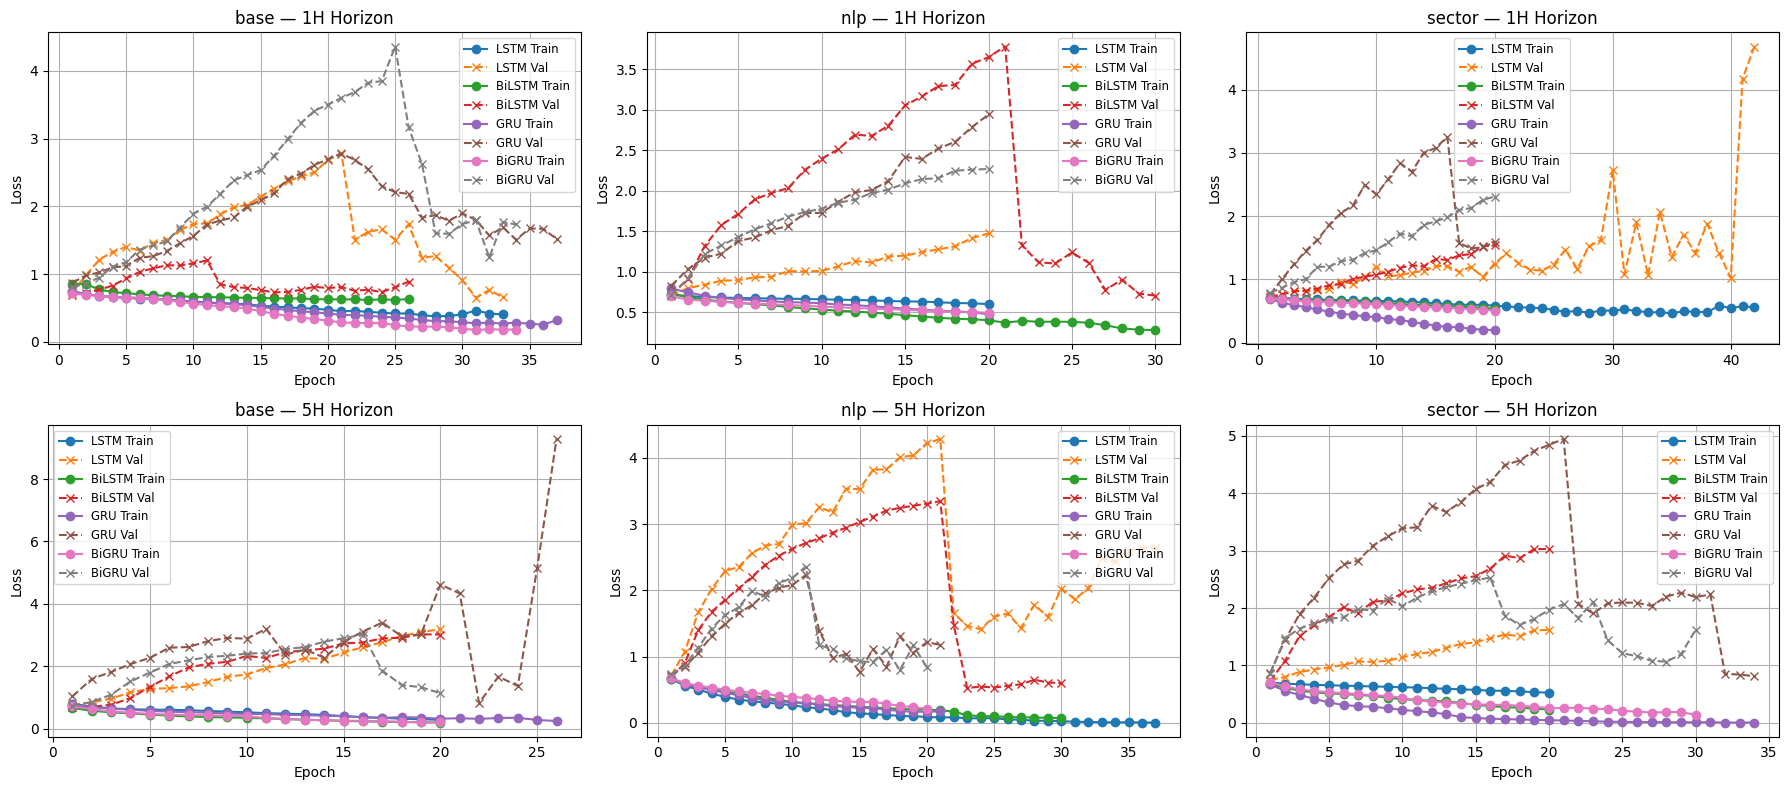

In [23]:
n_rows = len(horizons)
n_cols = len(features)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

for r, h in enumerate(horizons):
    for c, feature in enumerate(features):
        ax = axes[r][c]
        for model_name in models:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            avg_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()
            ax.plot(avg_loss["epoch"], avg_loss["train_loss"], label=f"{model_name} Train", marker='o')
            ax.plot(avg_loss["epoch"], avg_loss["val_loss"],   label=f"{model_name} Val",   marker='x', linestyle='--')
        ax.set_title(f"{feature} — {h}H Horizon")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend(fontsize='small', loc='best')

plt.tight_layout()
plt.show()

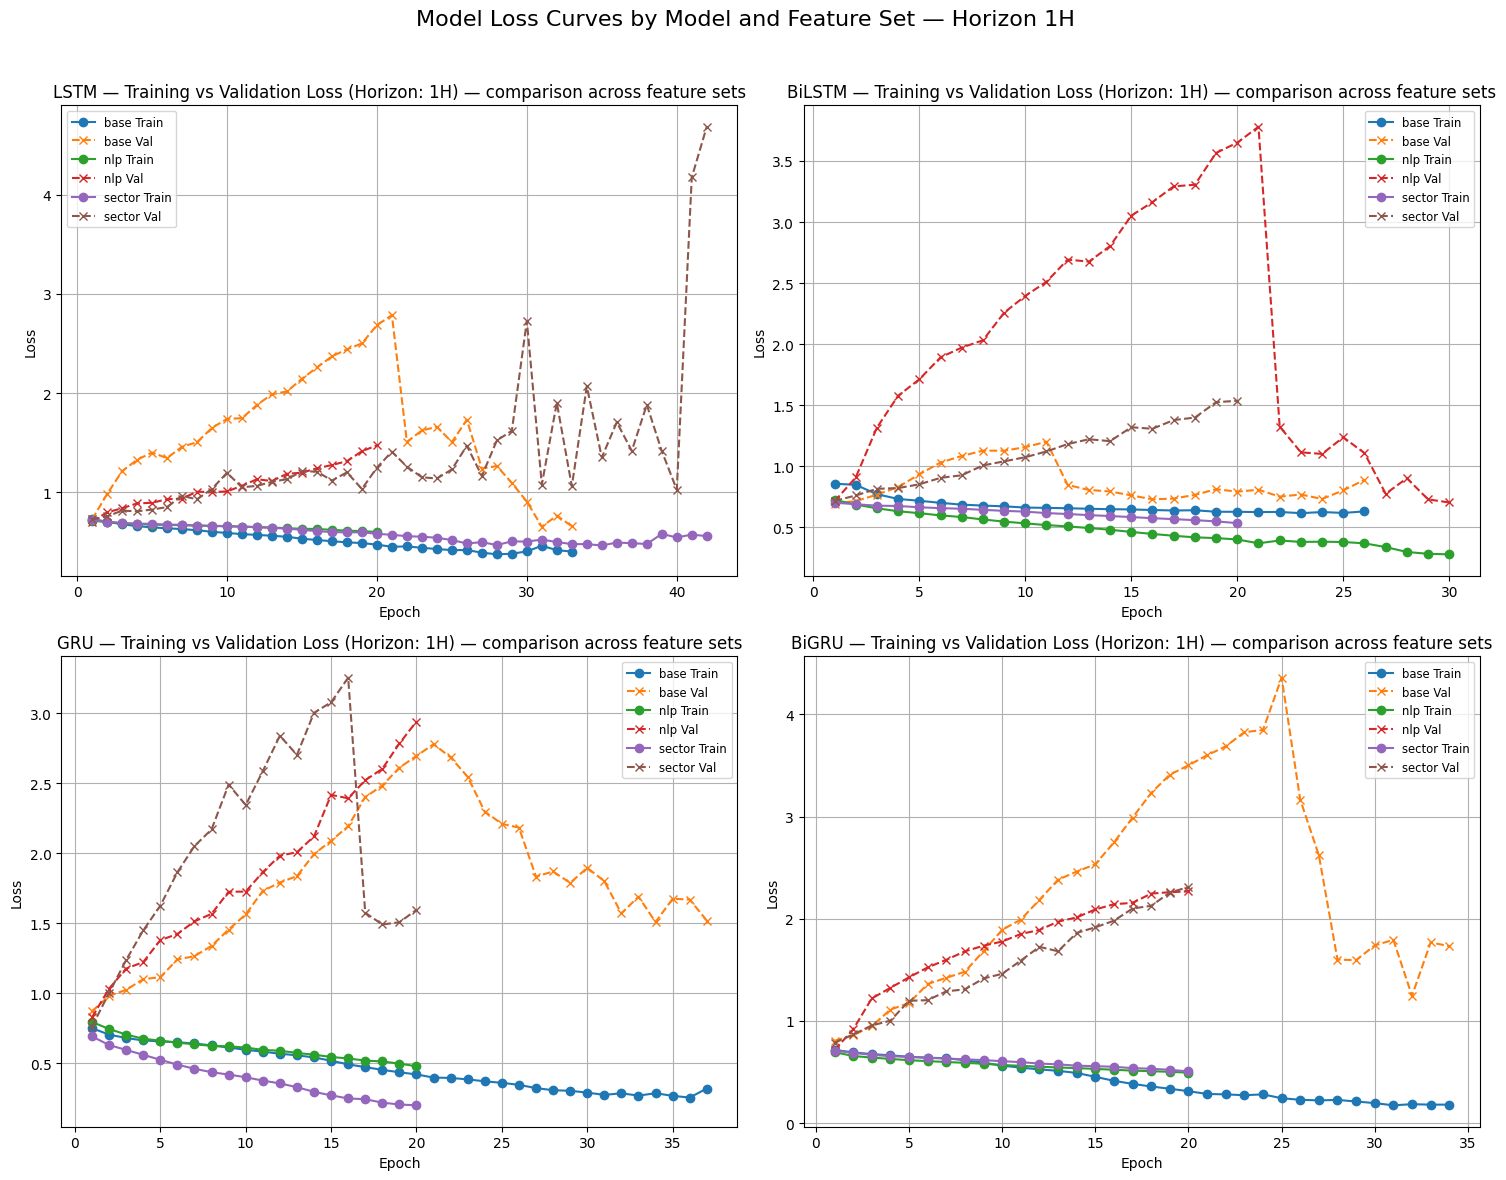

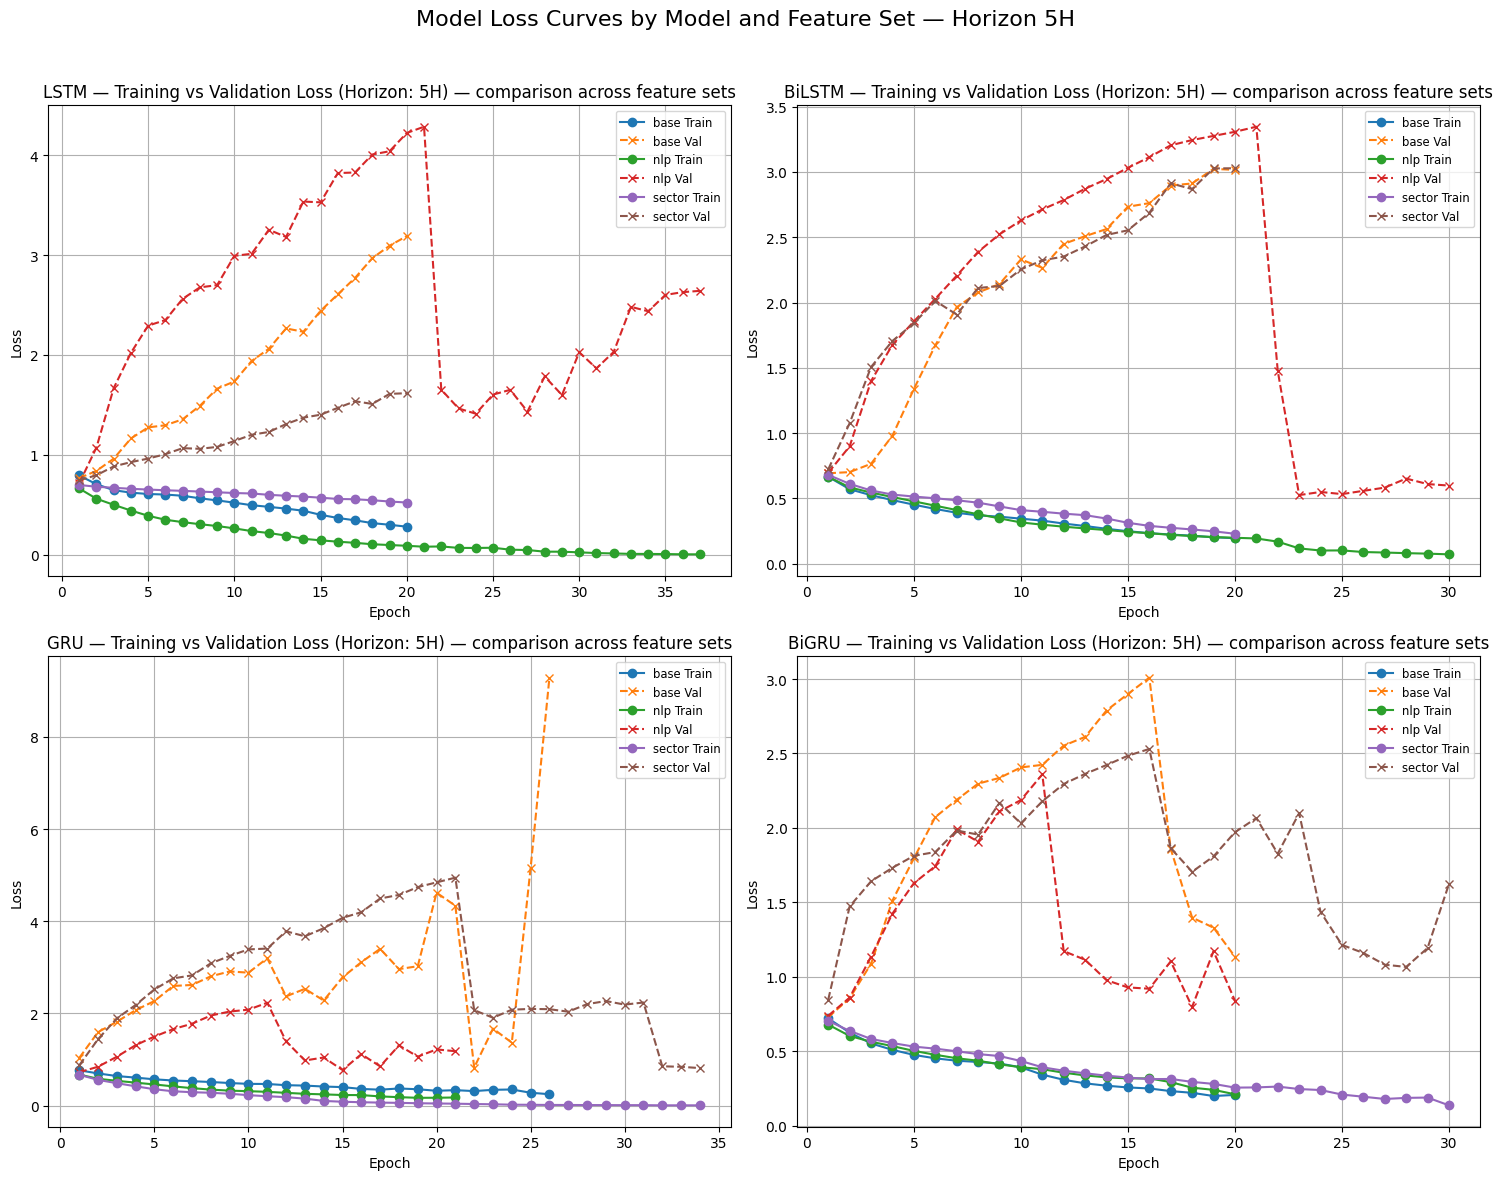

In [11]:
for h in horizons:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, model_name in enumerate(models):
        ax = axes[i]
        plotted = False
        for feature in features:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            avg_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()

            ax.plot(avg_loss["epoch"], avg_loss["train_loss"], label=f"{feature} Train", marker='o')
            ax.plot(avg_loss["epoch"], avg_loss["val_loss"],   label=f"{feature} Val",   marker='x', linestyle='--')
            plotted = True

        title = f"{model_name} — Training vs Validation Loss (Horizon: {h}H) — comparison across feature sets"
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        if plotted:
            ax.legend(fontsize='small', loc='best')
        else:
            ax.text(0.5, 0.5, "No data available", ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])

    # remove any extra axes if models < 4
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Model Loss Curves by Model and Feature Set — Horizon {h}H", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Regression

In [18]:
results = []

for h in horizons:
    for model_name in models:
        for feature in features:
            csv_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            df = pd.read_csv(csv_path)

            df = df.sort_values(by="epoch")

            auc_train = np.trapz(df["train_loss"], df["epoch"])
            auc_val = np.trapz(df["val_loss"], df["epoch"])

            results.append({
                    "Model": model_name,
                    "Horizon": h,
                    "Feature Set": feature,
                    "AUC_Train": auc_train,
                    "AUC_Validation": auc_val
            })

            results_df = pd.DataFrame(results)
print(results_df)

     Model  Horizon Feature Set  AUC_Train  AUC_Validation
0     LSTM        1        base  12.356043       22.424528
1     LSTM        1         nlp   2.081759        2.860584
2     LSTM        1      sector   3.239726        4.501419
3   BiLSTM        1        base   4.388266        6.064601
4   BiLSTM        1         nlp  10.881670       16.652283
5   BiLSTM        1      sector   1.634624        2.291697
6      GRU        1        base   1.725307        2.386197
7      GRU        1         nlp  13.900930       27.248439
8      GRU        1      sector   4.506071        6.821399
9    BiGRU        1        base   2.511385        3.877284
10   BiGRU        1         nlp  15.024874       30.091637
11   BiGRU        1      sector  18.550566       29.812682
12    LSTM        5        base  10.042721       17.613158
13    LSTM        5         nlp   7.600428       13.328753
14    LSTM        5      sector   1.129791        2.212884
15  BiLSTM        5        base   7.156125       11.9021

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

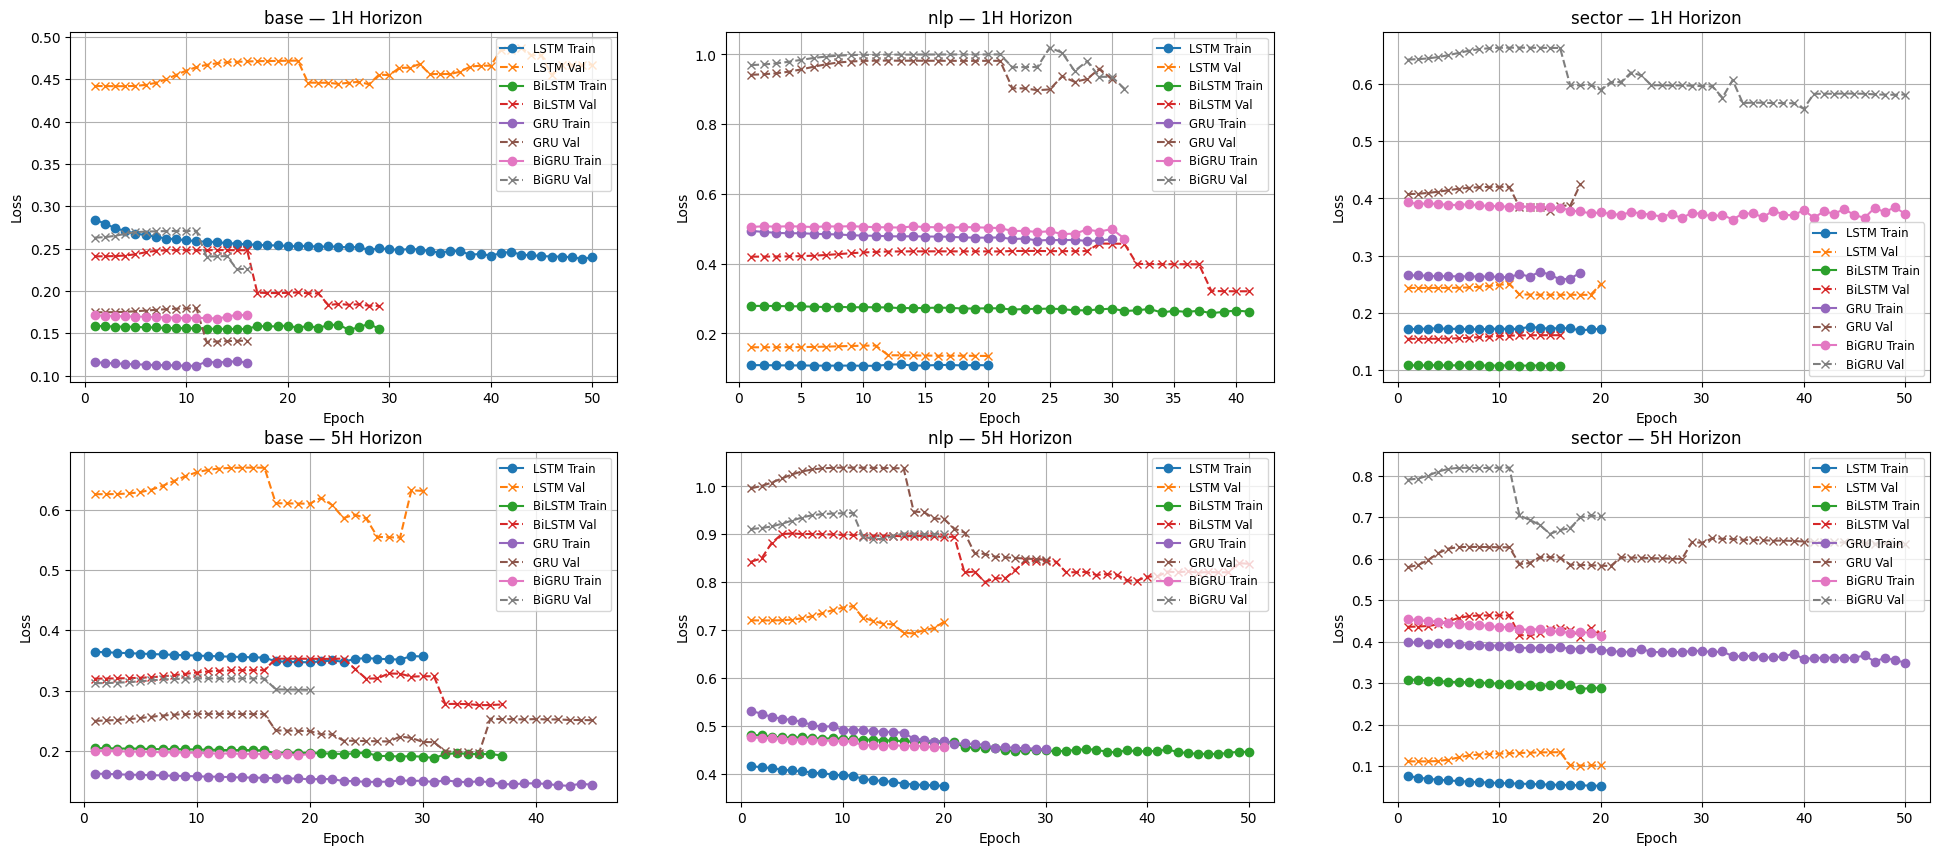

In [22]:
n_rows = len(horizons)
n_cols = len(features)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), squeeze=False)

for r, h in enumerate(horizons):
    for c, feature in enumerate(features):
        ax = axes[r][c]
        for model_name in models:
            csv_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            avg_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()
            ax.plot(avg_loss["epoch"], avg_loss["train_loss"], label=f"{model_name} Train", marker='o')
            ax.plot(avg_loss["epoch"], avg_loss["val_loss"],   label=f"{model_name} Val",   marker='x', linestyle='--')
        ax.set_title(f"{feature} — {h}H Horizon")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend(fontsize='small', loc='best')

plt.tight_layout

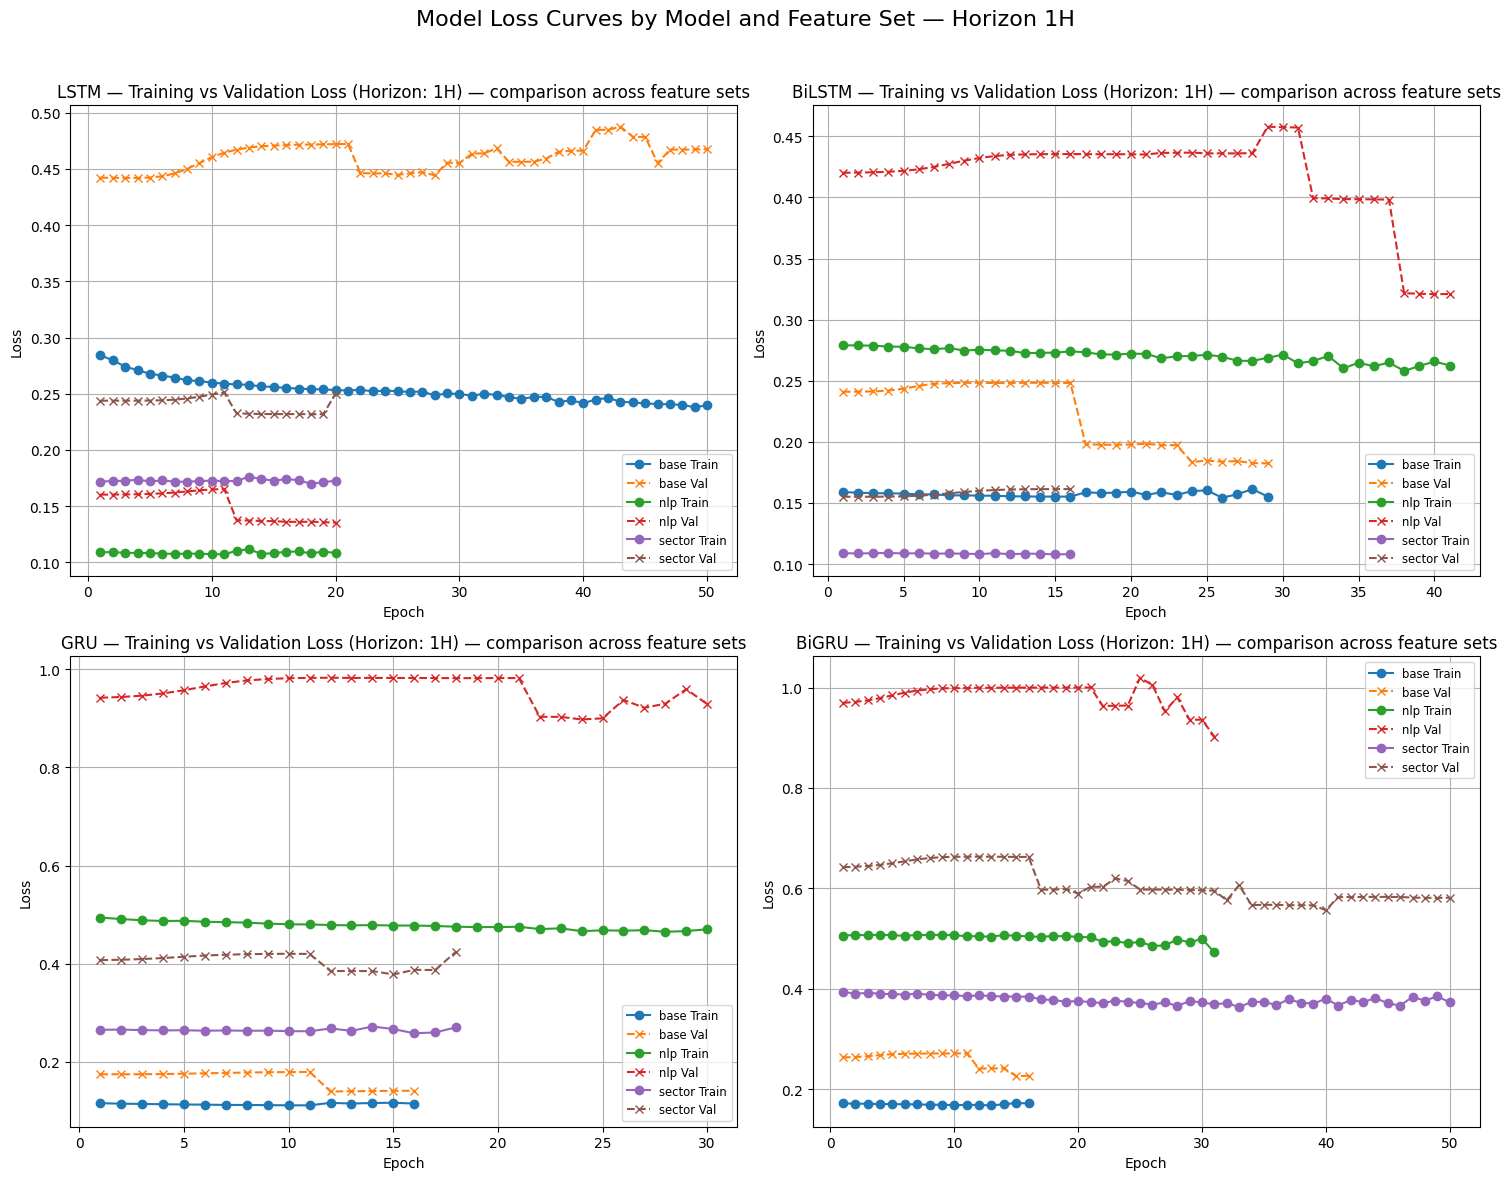

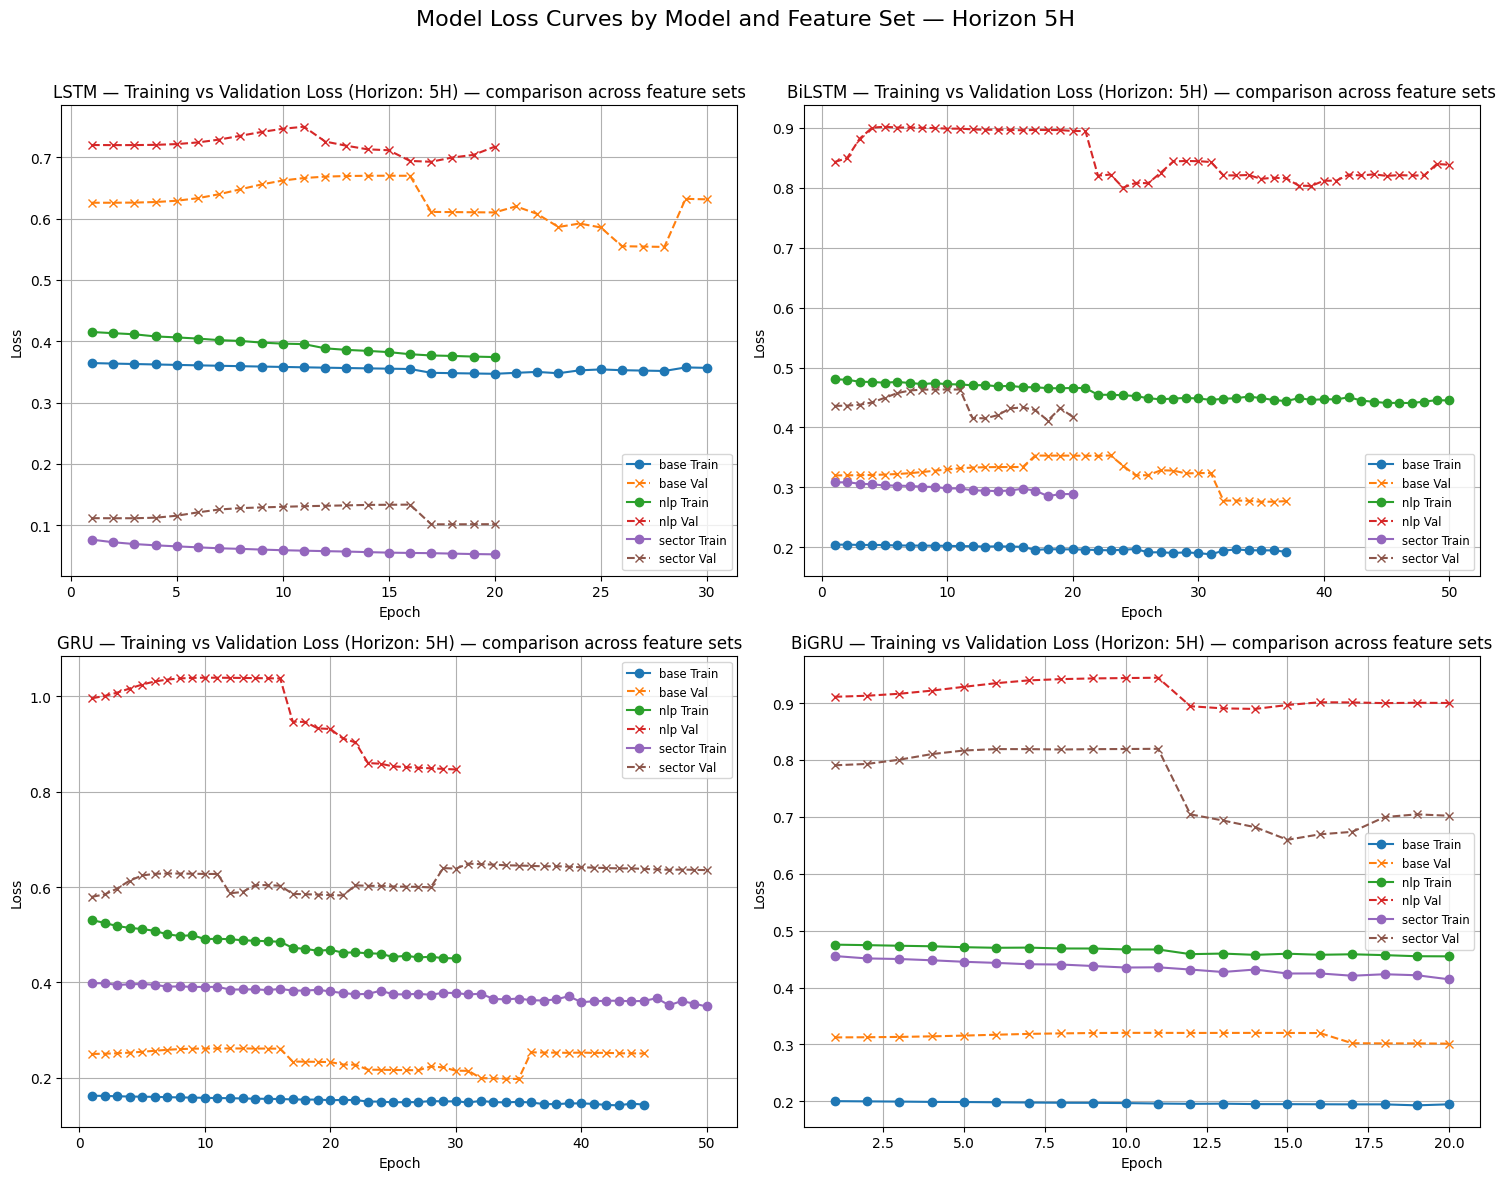

In [25]:
for h in horizons:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, model_name in enumerate(models):
        ax = axes[i]
        plotted = False
        for feature in features:
            csv_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            avg_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()

            ax.plot(avg_loss["epoch"], avg_loss["train_loss"], label=f"{feature} Train", marker='o')
            ax.plot(avg_loss["epoch"], avg_loss["val_loss"],   label=f"{feature} Val",   marker='x', linestyle='--')
            plotted = True

        title = f"{model_name} — Training vs Validation Loss (Horizon: {h}H) — comparison across feature sets"
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        if plotted:
            ax.legend(fontsize='small', loc='best')
        else:
            ax.text(0.5, 0.5, "No data available", ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])

    # remove any extra axes if models < 4
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Model Loss Curves by Model and Feature Set — Horizon {h}H", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### Sector Specific


#### Classification

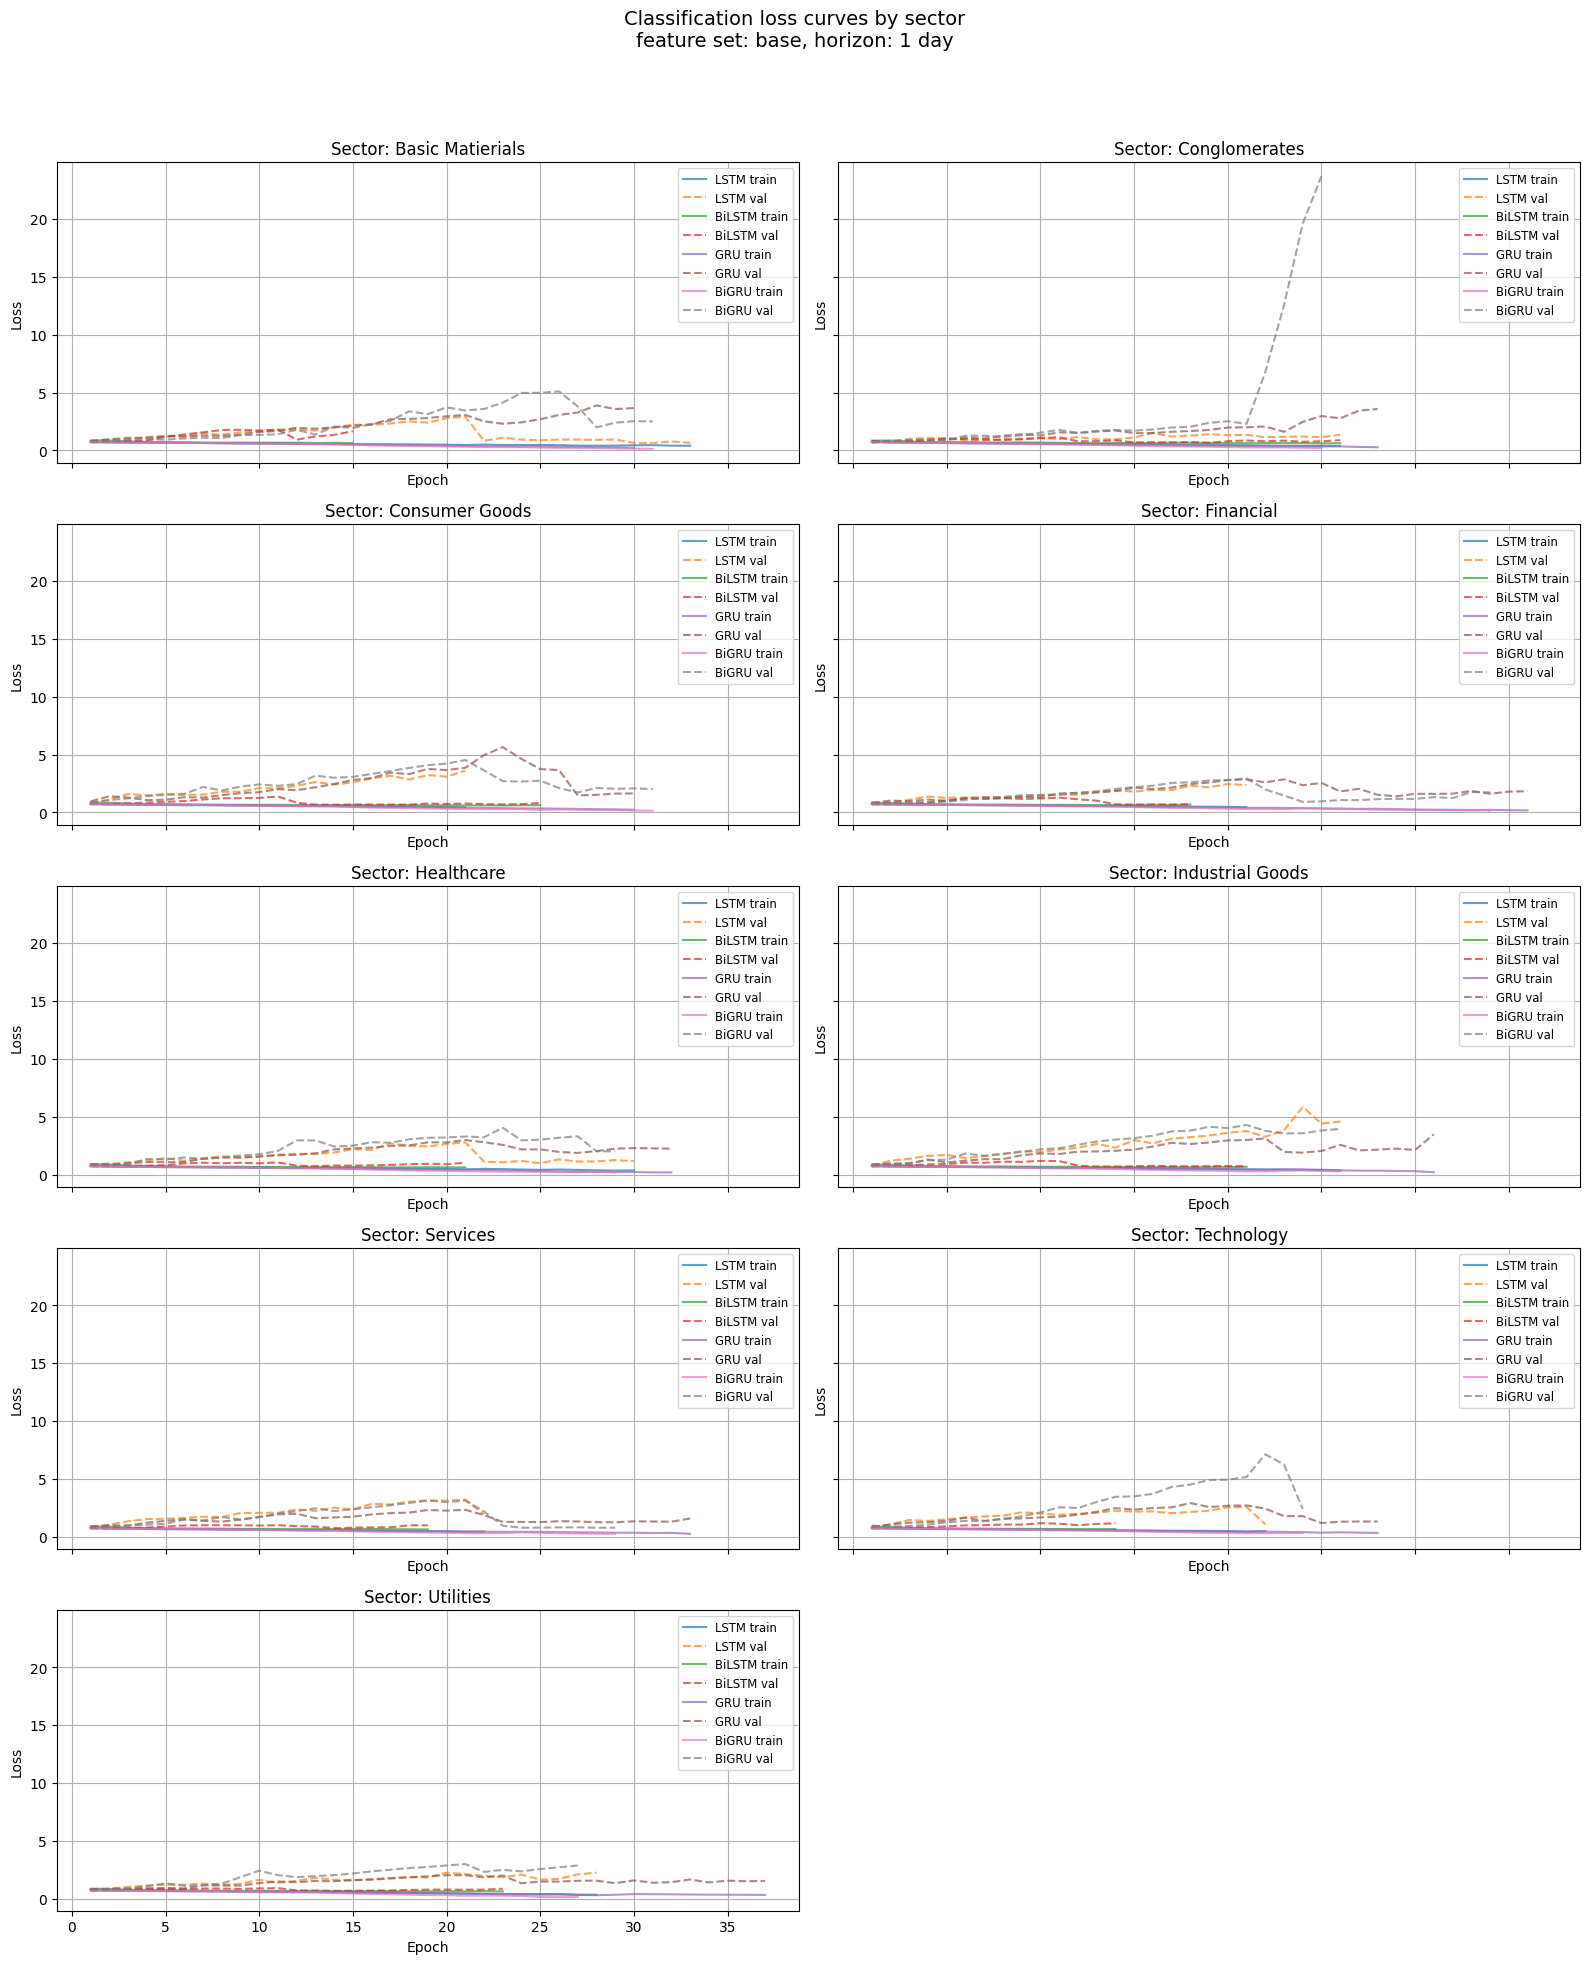

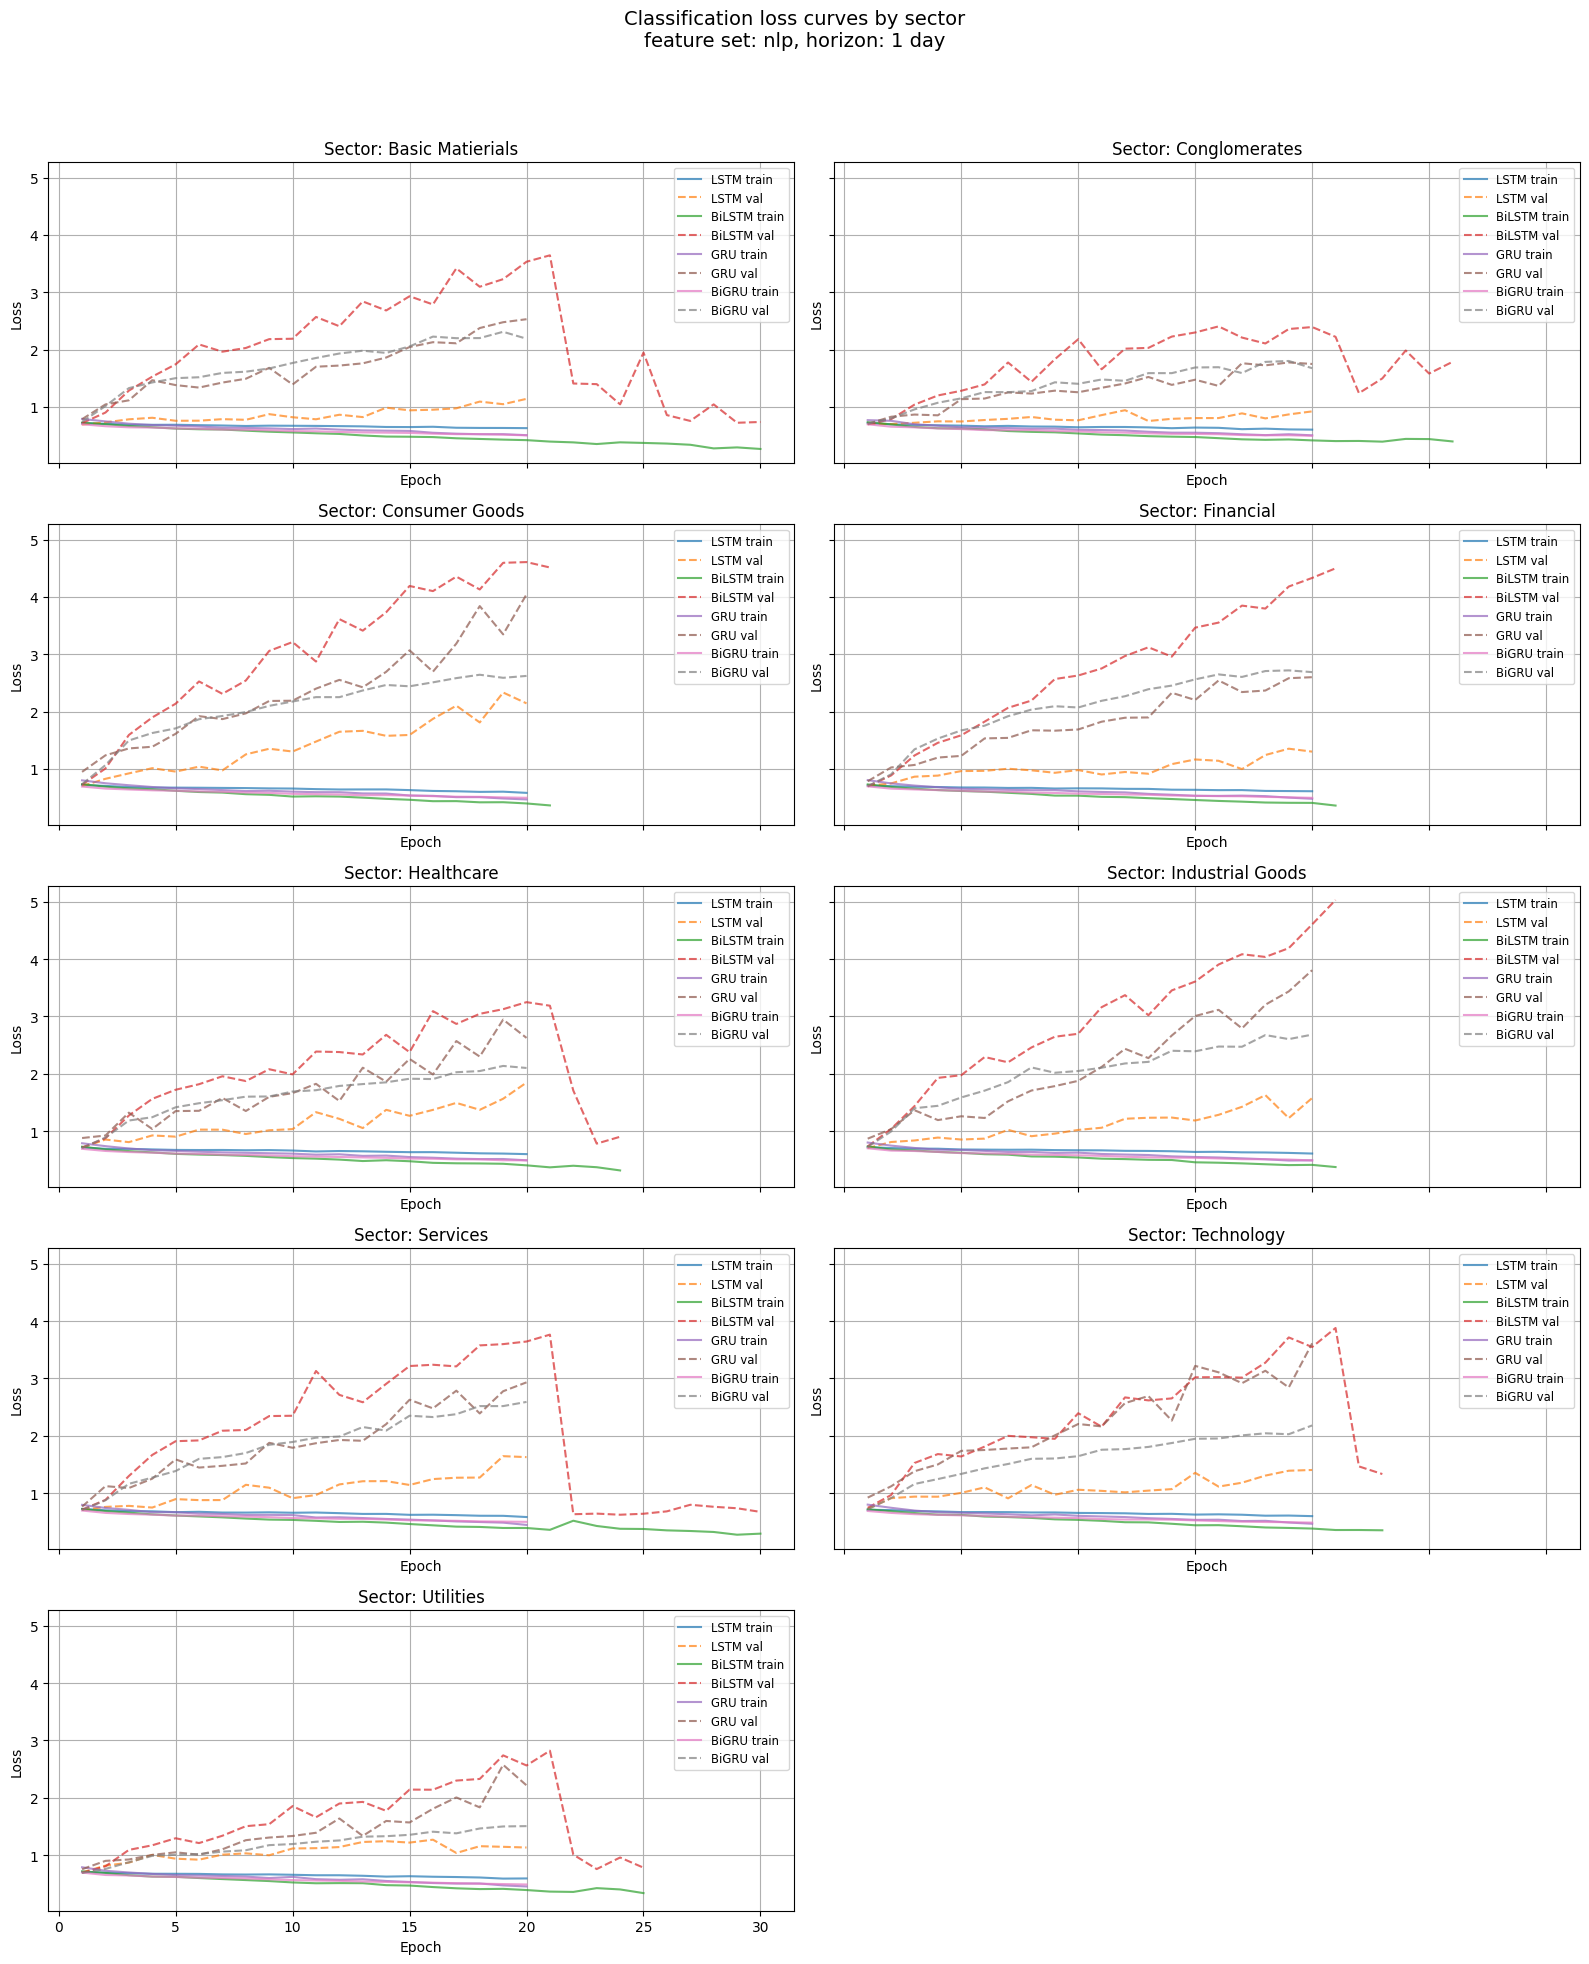

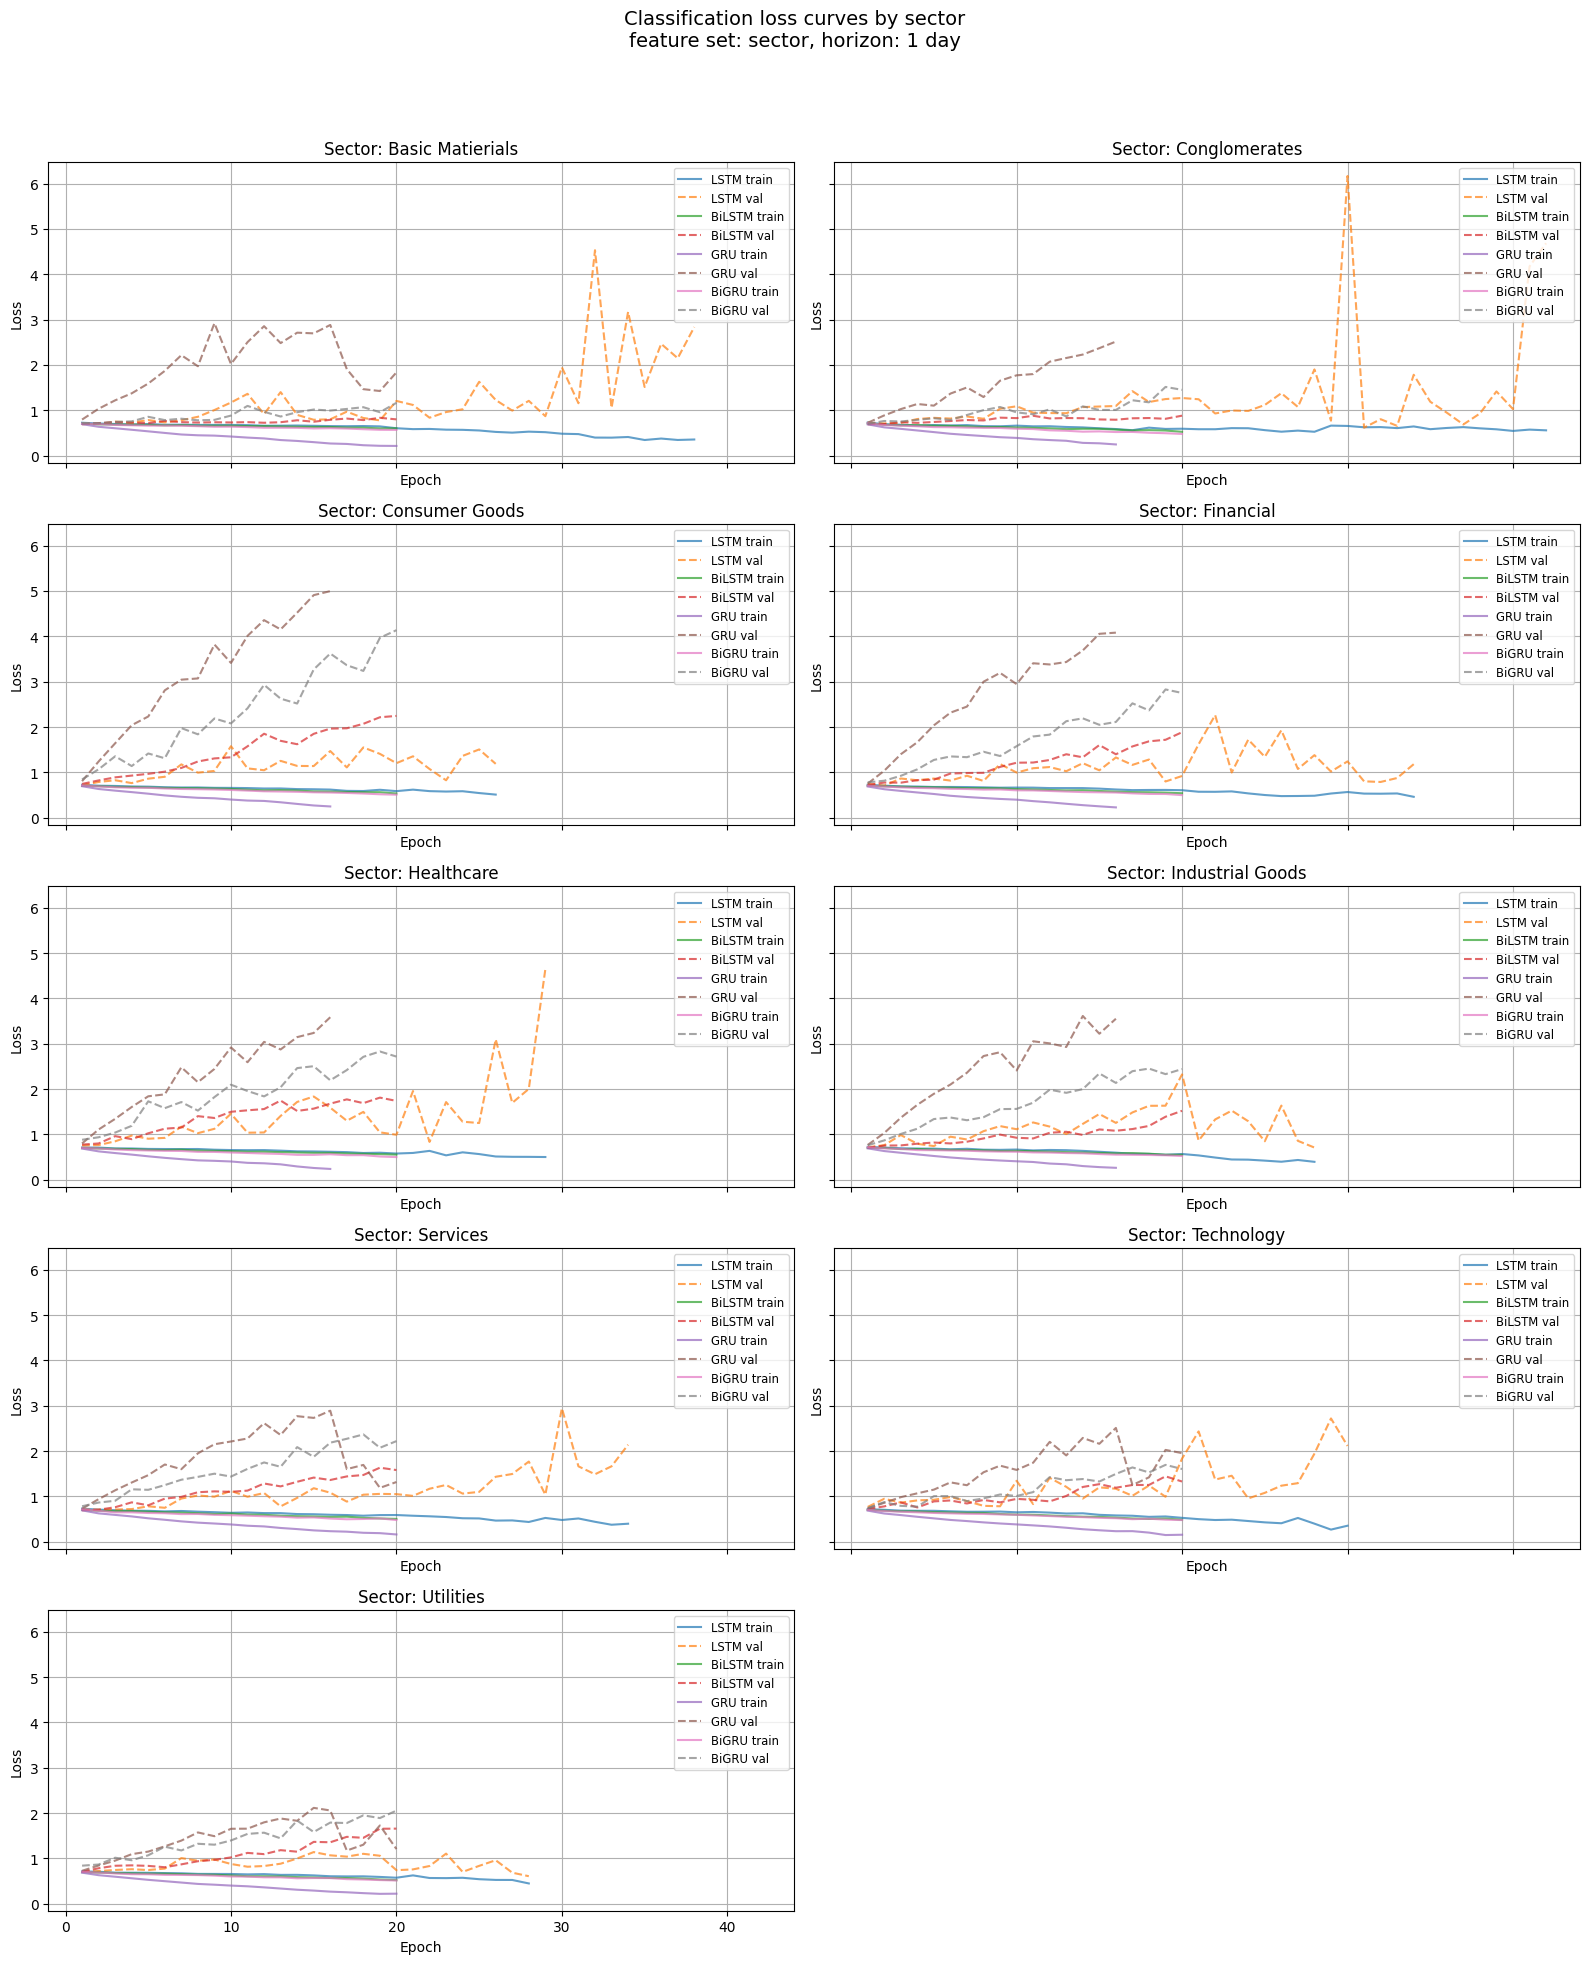

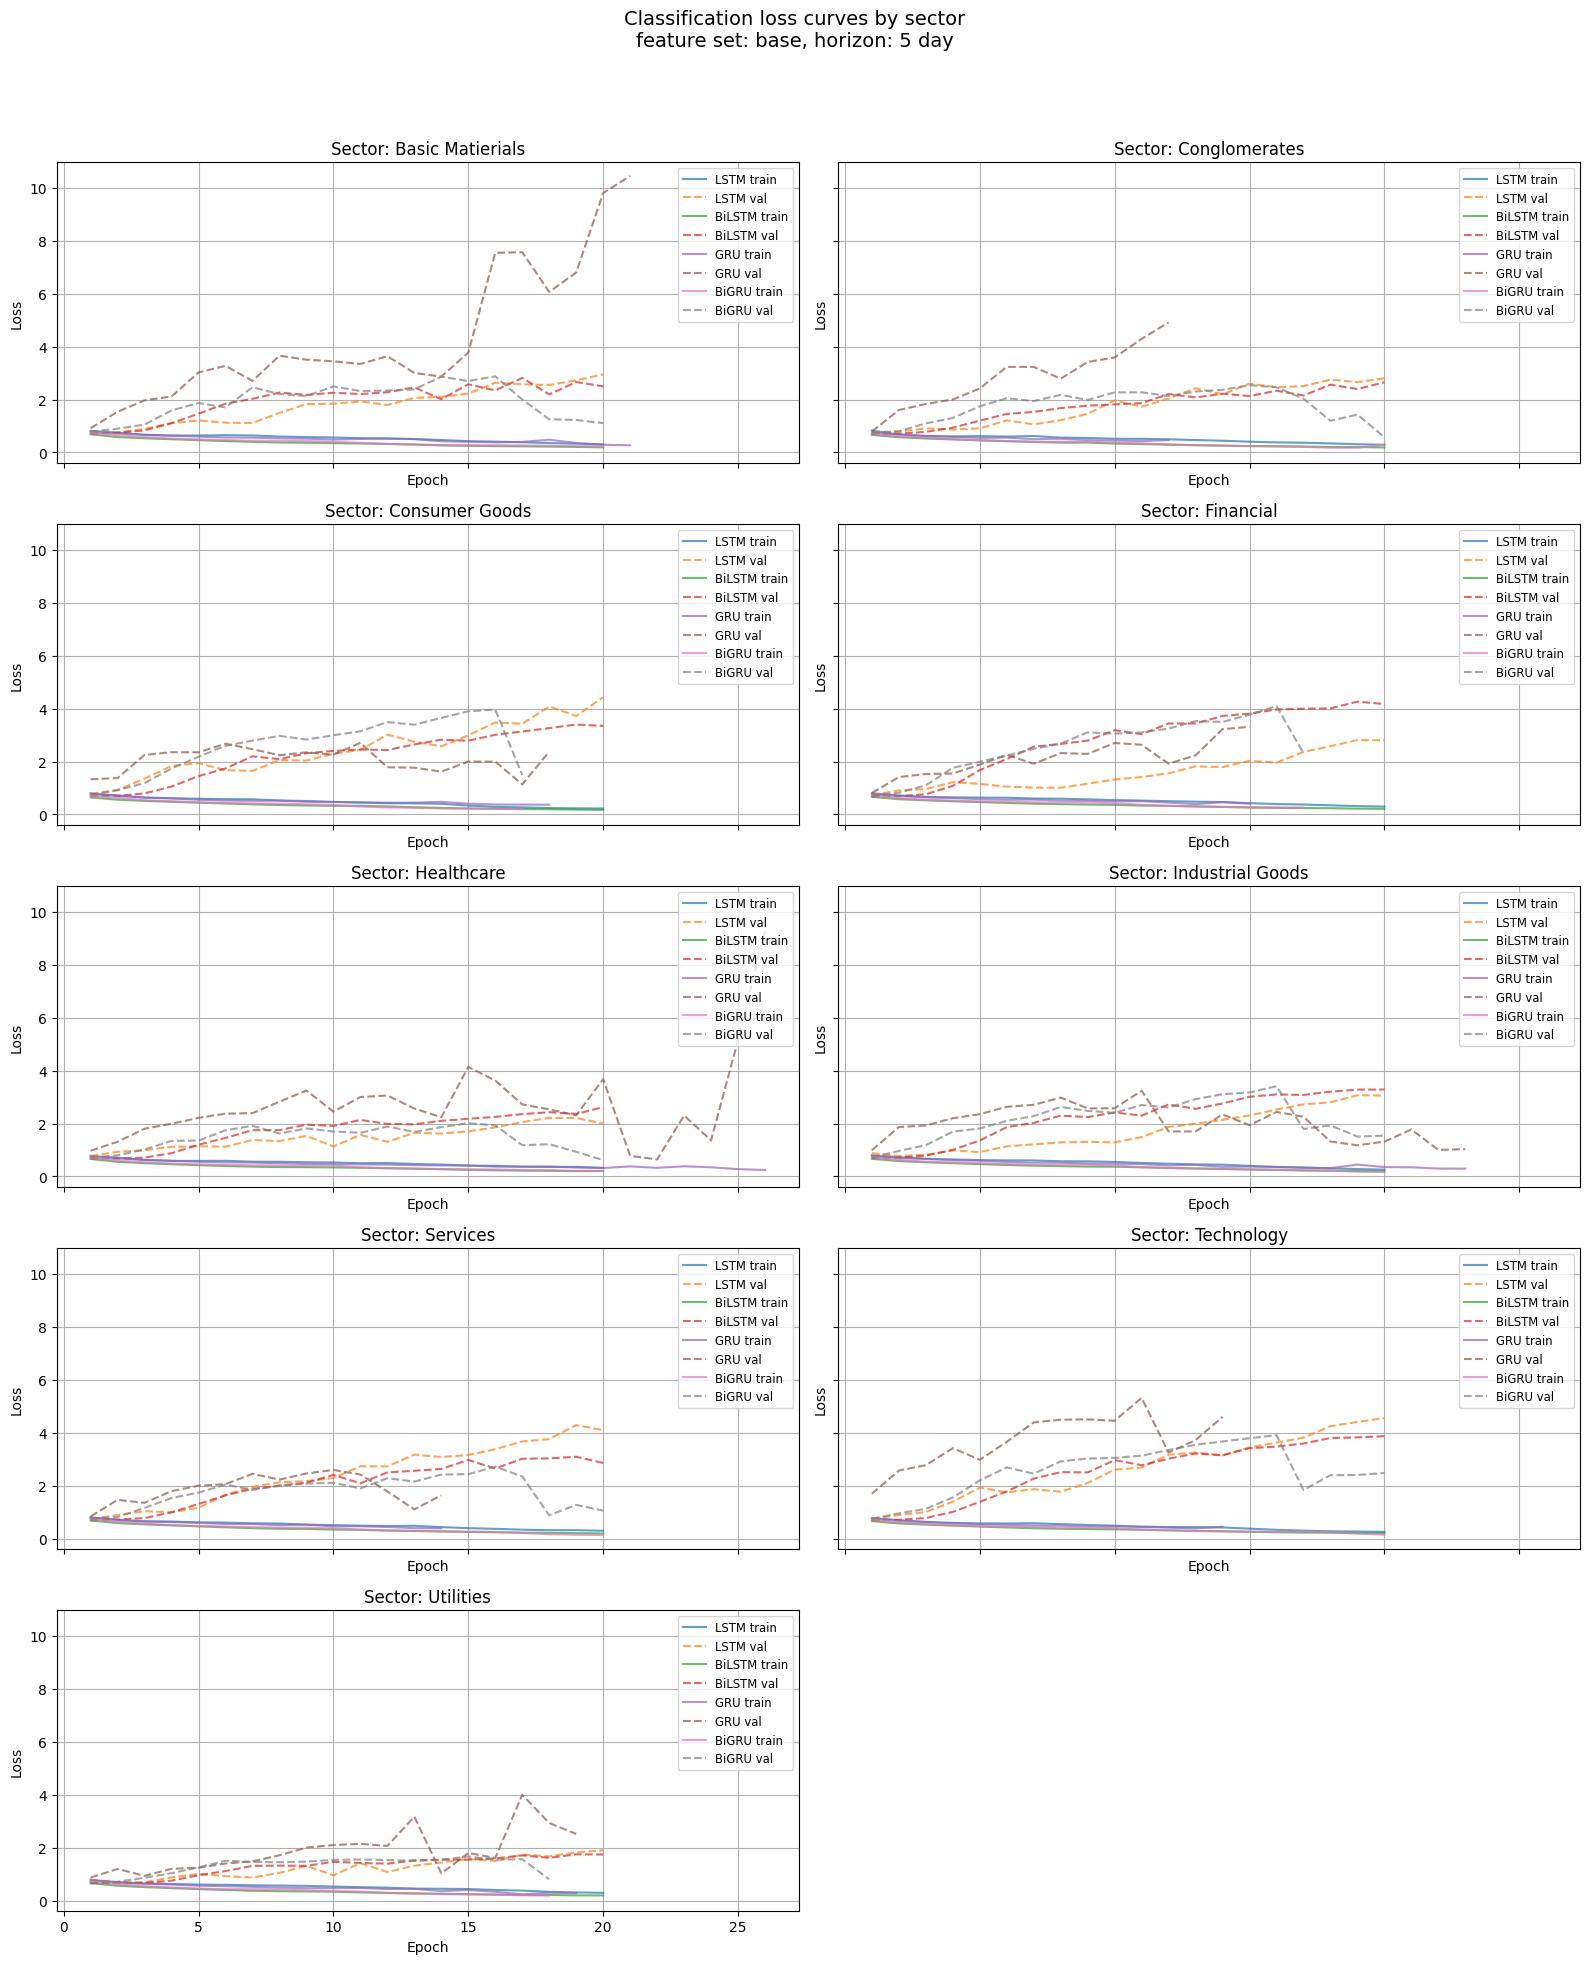

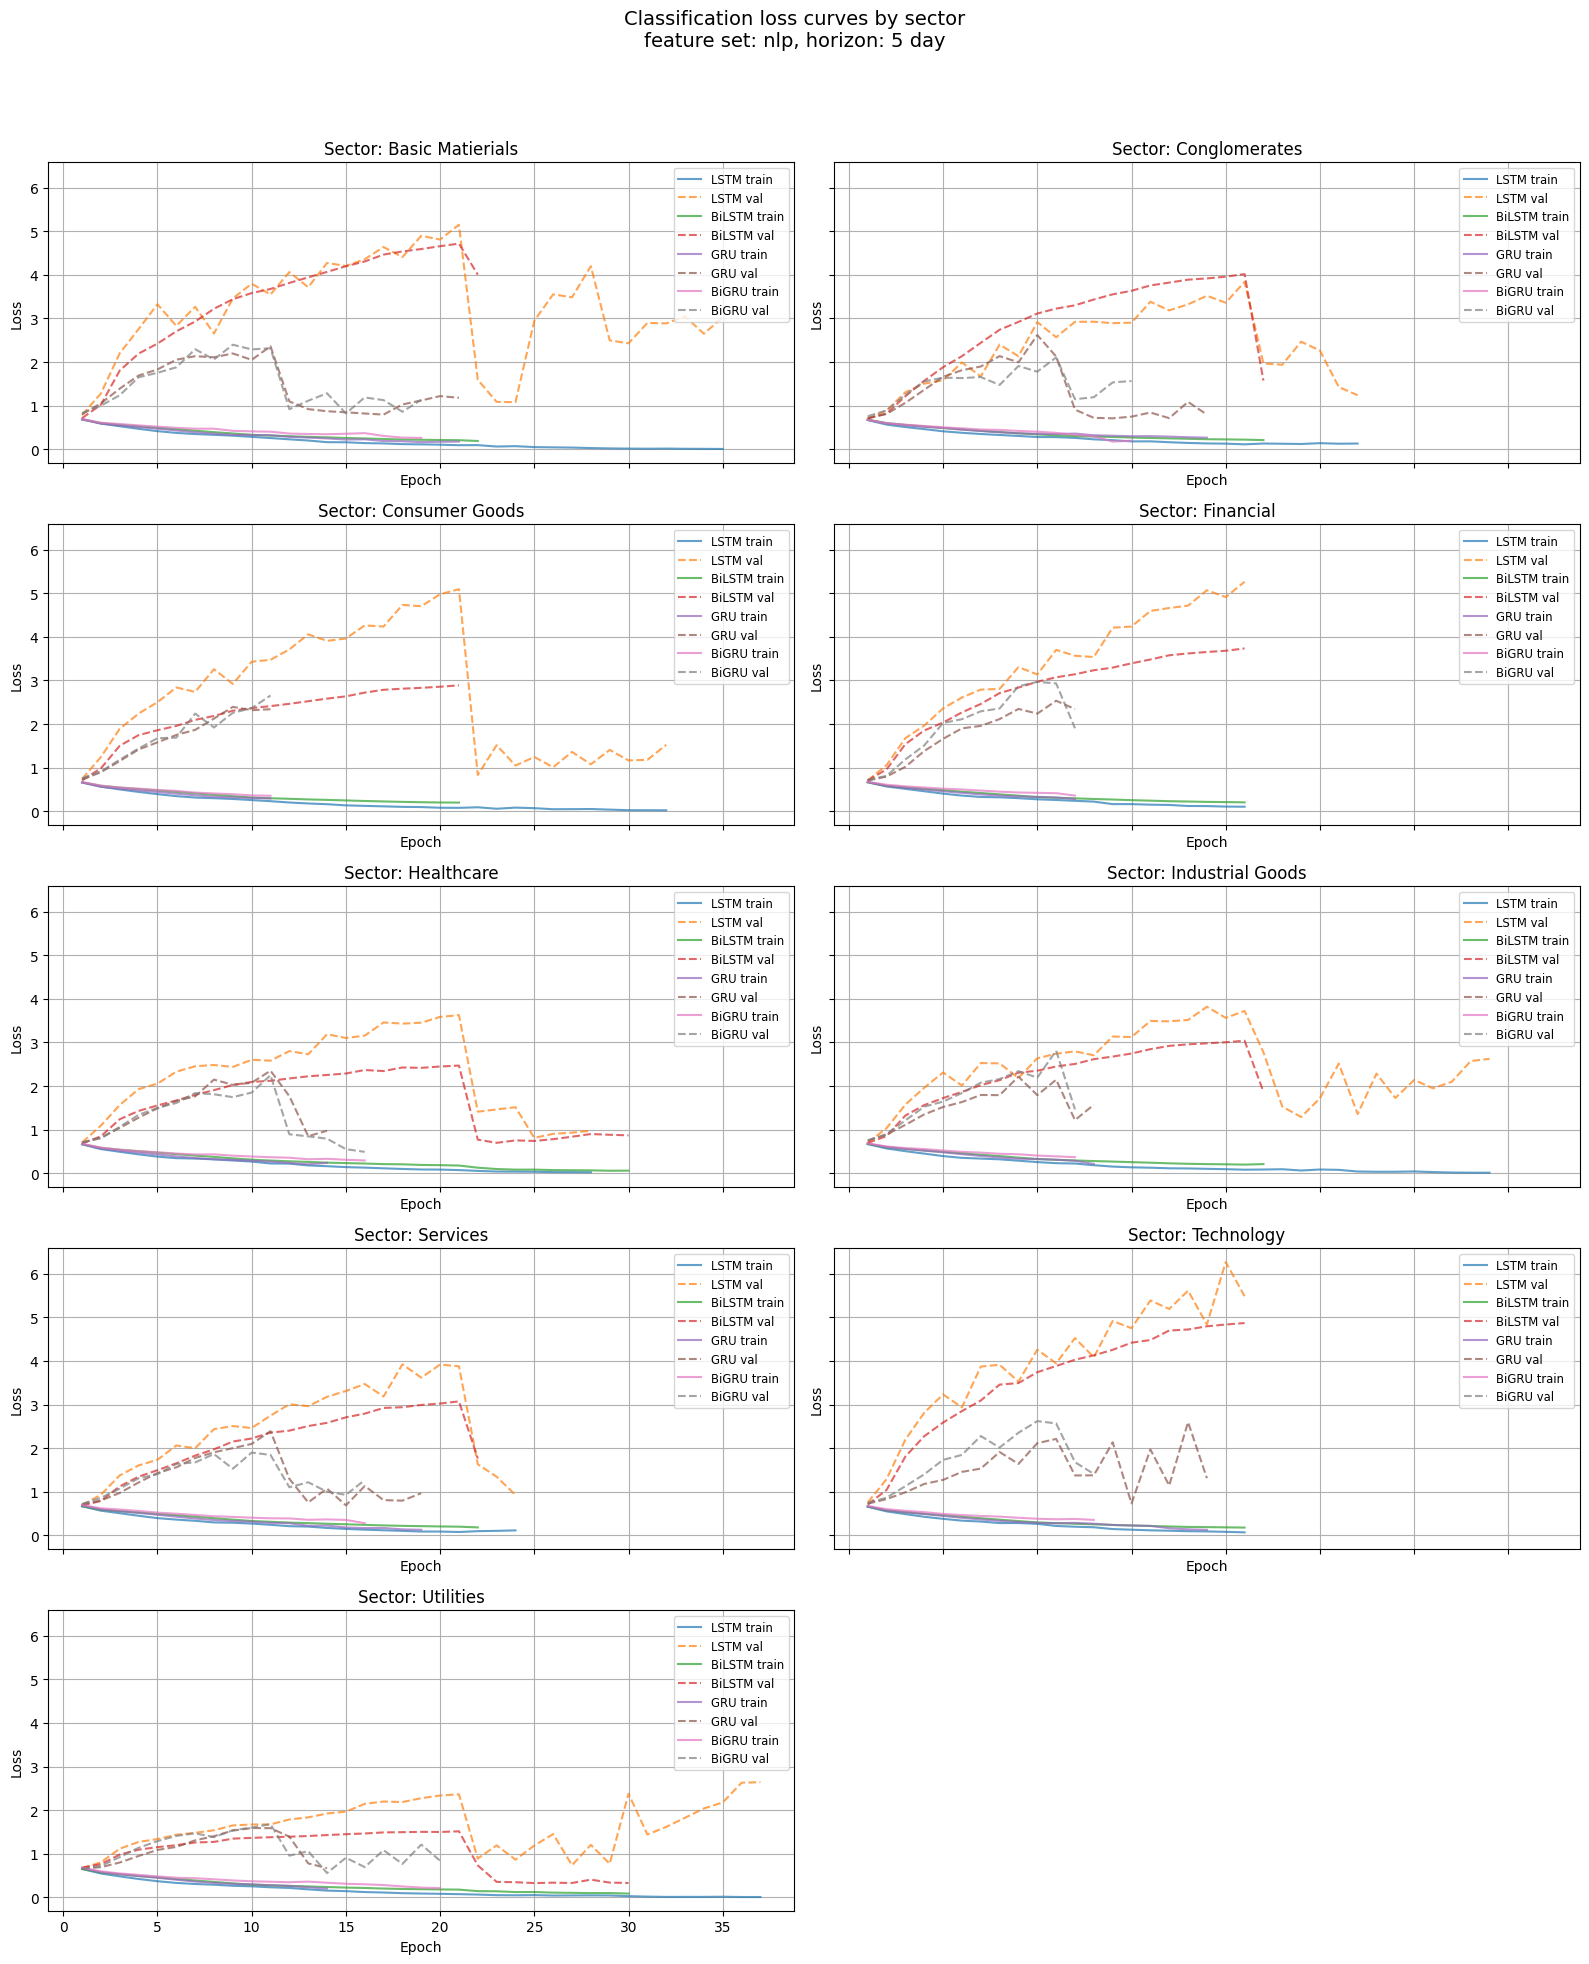

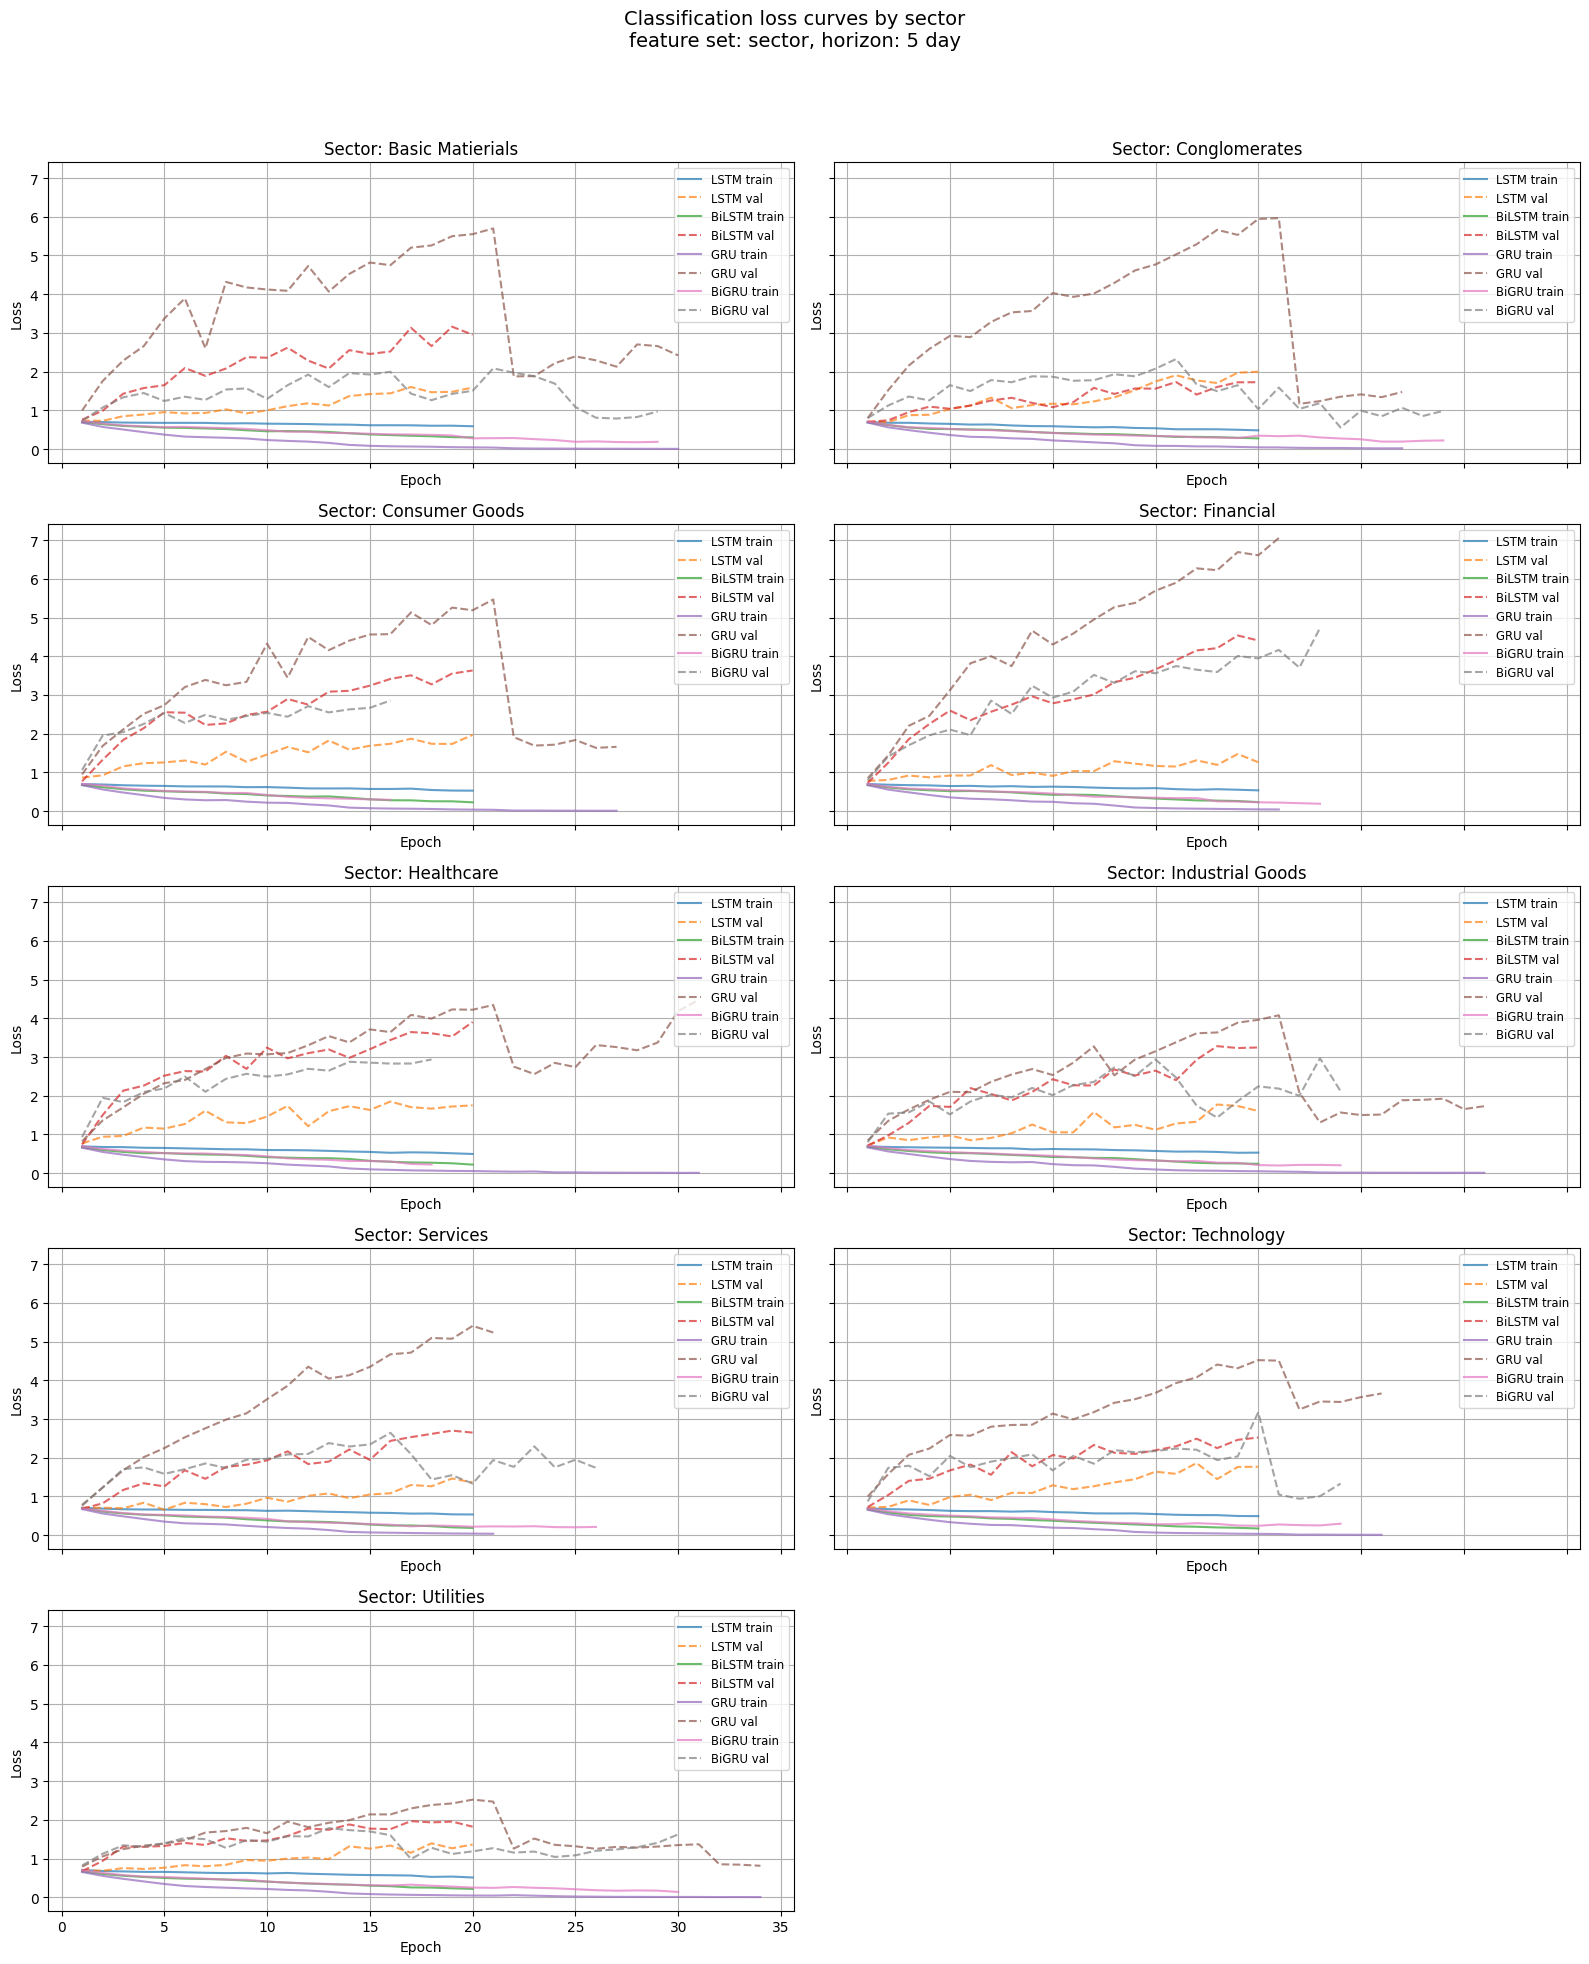

In [26]:
for h in horizons:
    for feature in features:
        # gather data just for this horizon/feature set
        pieces = []
        for model_name in models:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            df["model"] = model_name
            pieces.append(df)
        if not pieces:                          # nothing to plot
            continue

        combined_df = pd.concat(pieces, ignore_index=True)
        grouped_loss = (combined_df
                        .groupby(["sector", "model", "epoch"])
                        [["train_loss", "val_loss"]]
                        .mean()
                        .reset_index())

        sectors = grouped_loss["sector"].unique()
        n_cols = 2
        n_rows = -(-len(sectors) // n_cols)

        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(16, 4 * n_rows),
                                 sharex=True, sharey=True)
        axes = axes.flatten()

        for i, sector in enumerate(sectors):
            ax = axes[i]
            sector_data = grouped_loss[grouped_loss["sector"] == sector]
            for model_name in models:
                model_data = sector_data[sector_data["model"] == model_name]
                if model_data.empty:
                    continue
                ax.plot(model_data["epoch"], model_data["train_loss"],
                        label=f"{model_name} train",
                        linestyle="-", alpha=0.7)
                ax.plot(model_data["epoch"], model_data["val_loss"],
                        label=f"{model_name} val",
                        linestyle="--", alpha=0.7)
            ax.set_title(f"Sector: {sector}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.grid(True)
            ax.legend(fontsize="small", loc="upper right")

        # remove any extra empty subplots
        for j in range(len(sectors), len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(
            f"Classification loss curves by sector\n"
            f"feature set: {feature}, horizon: {h} day",
            fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

#### Regression

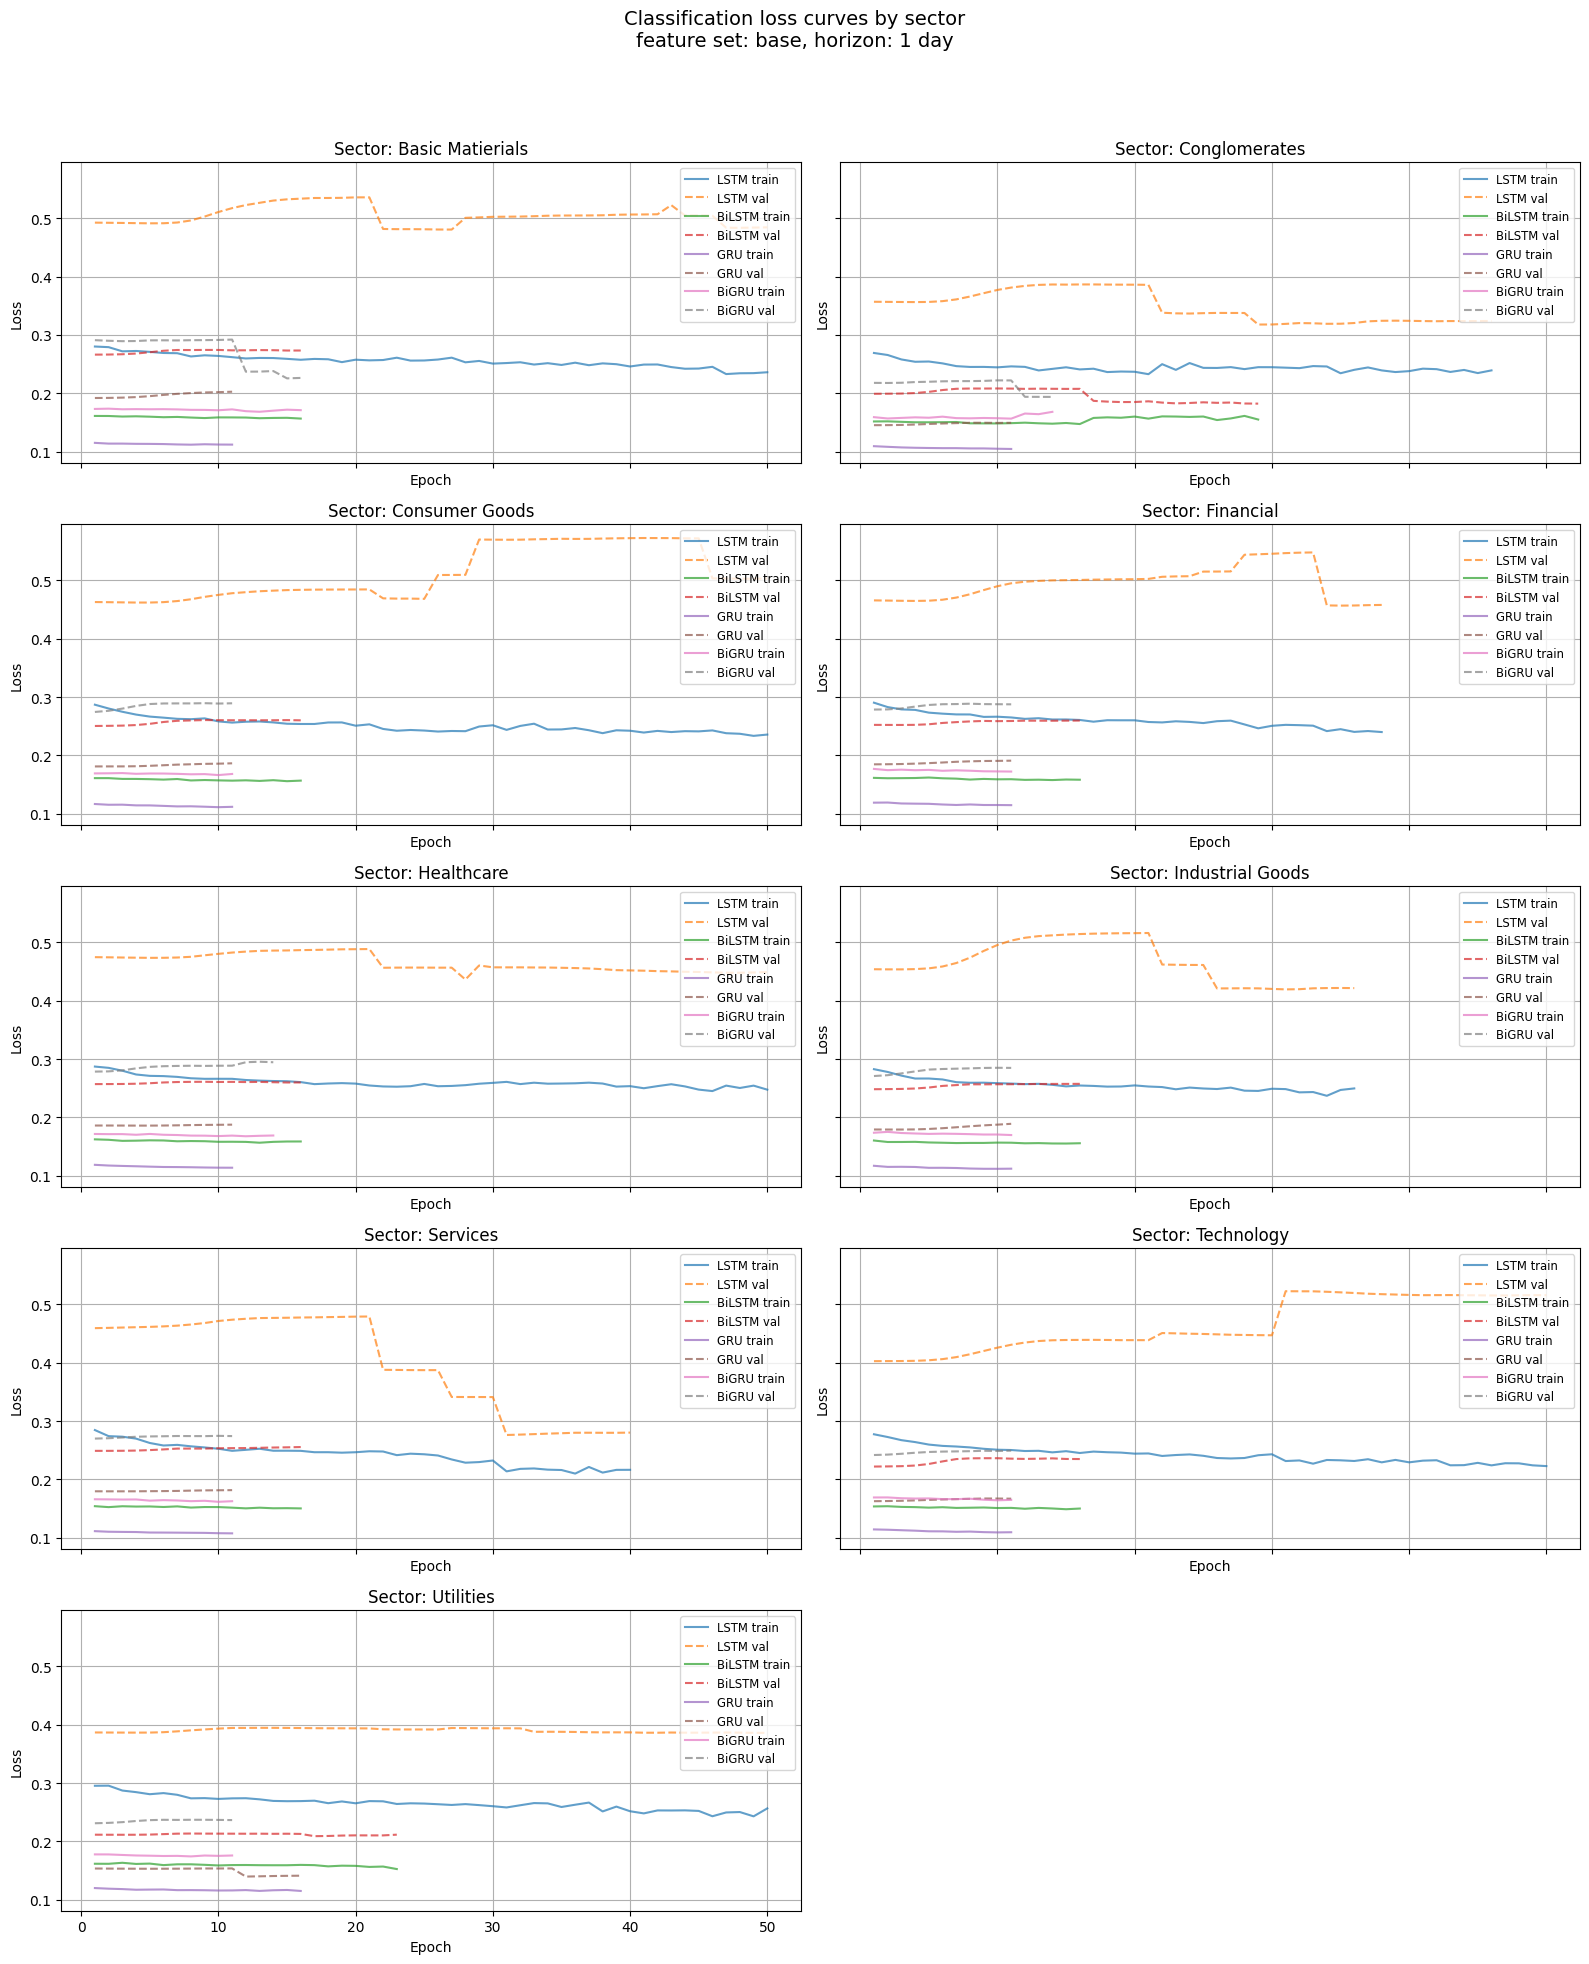

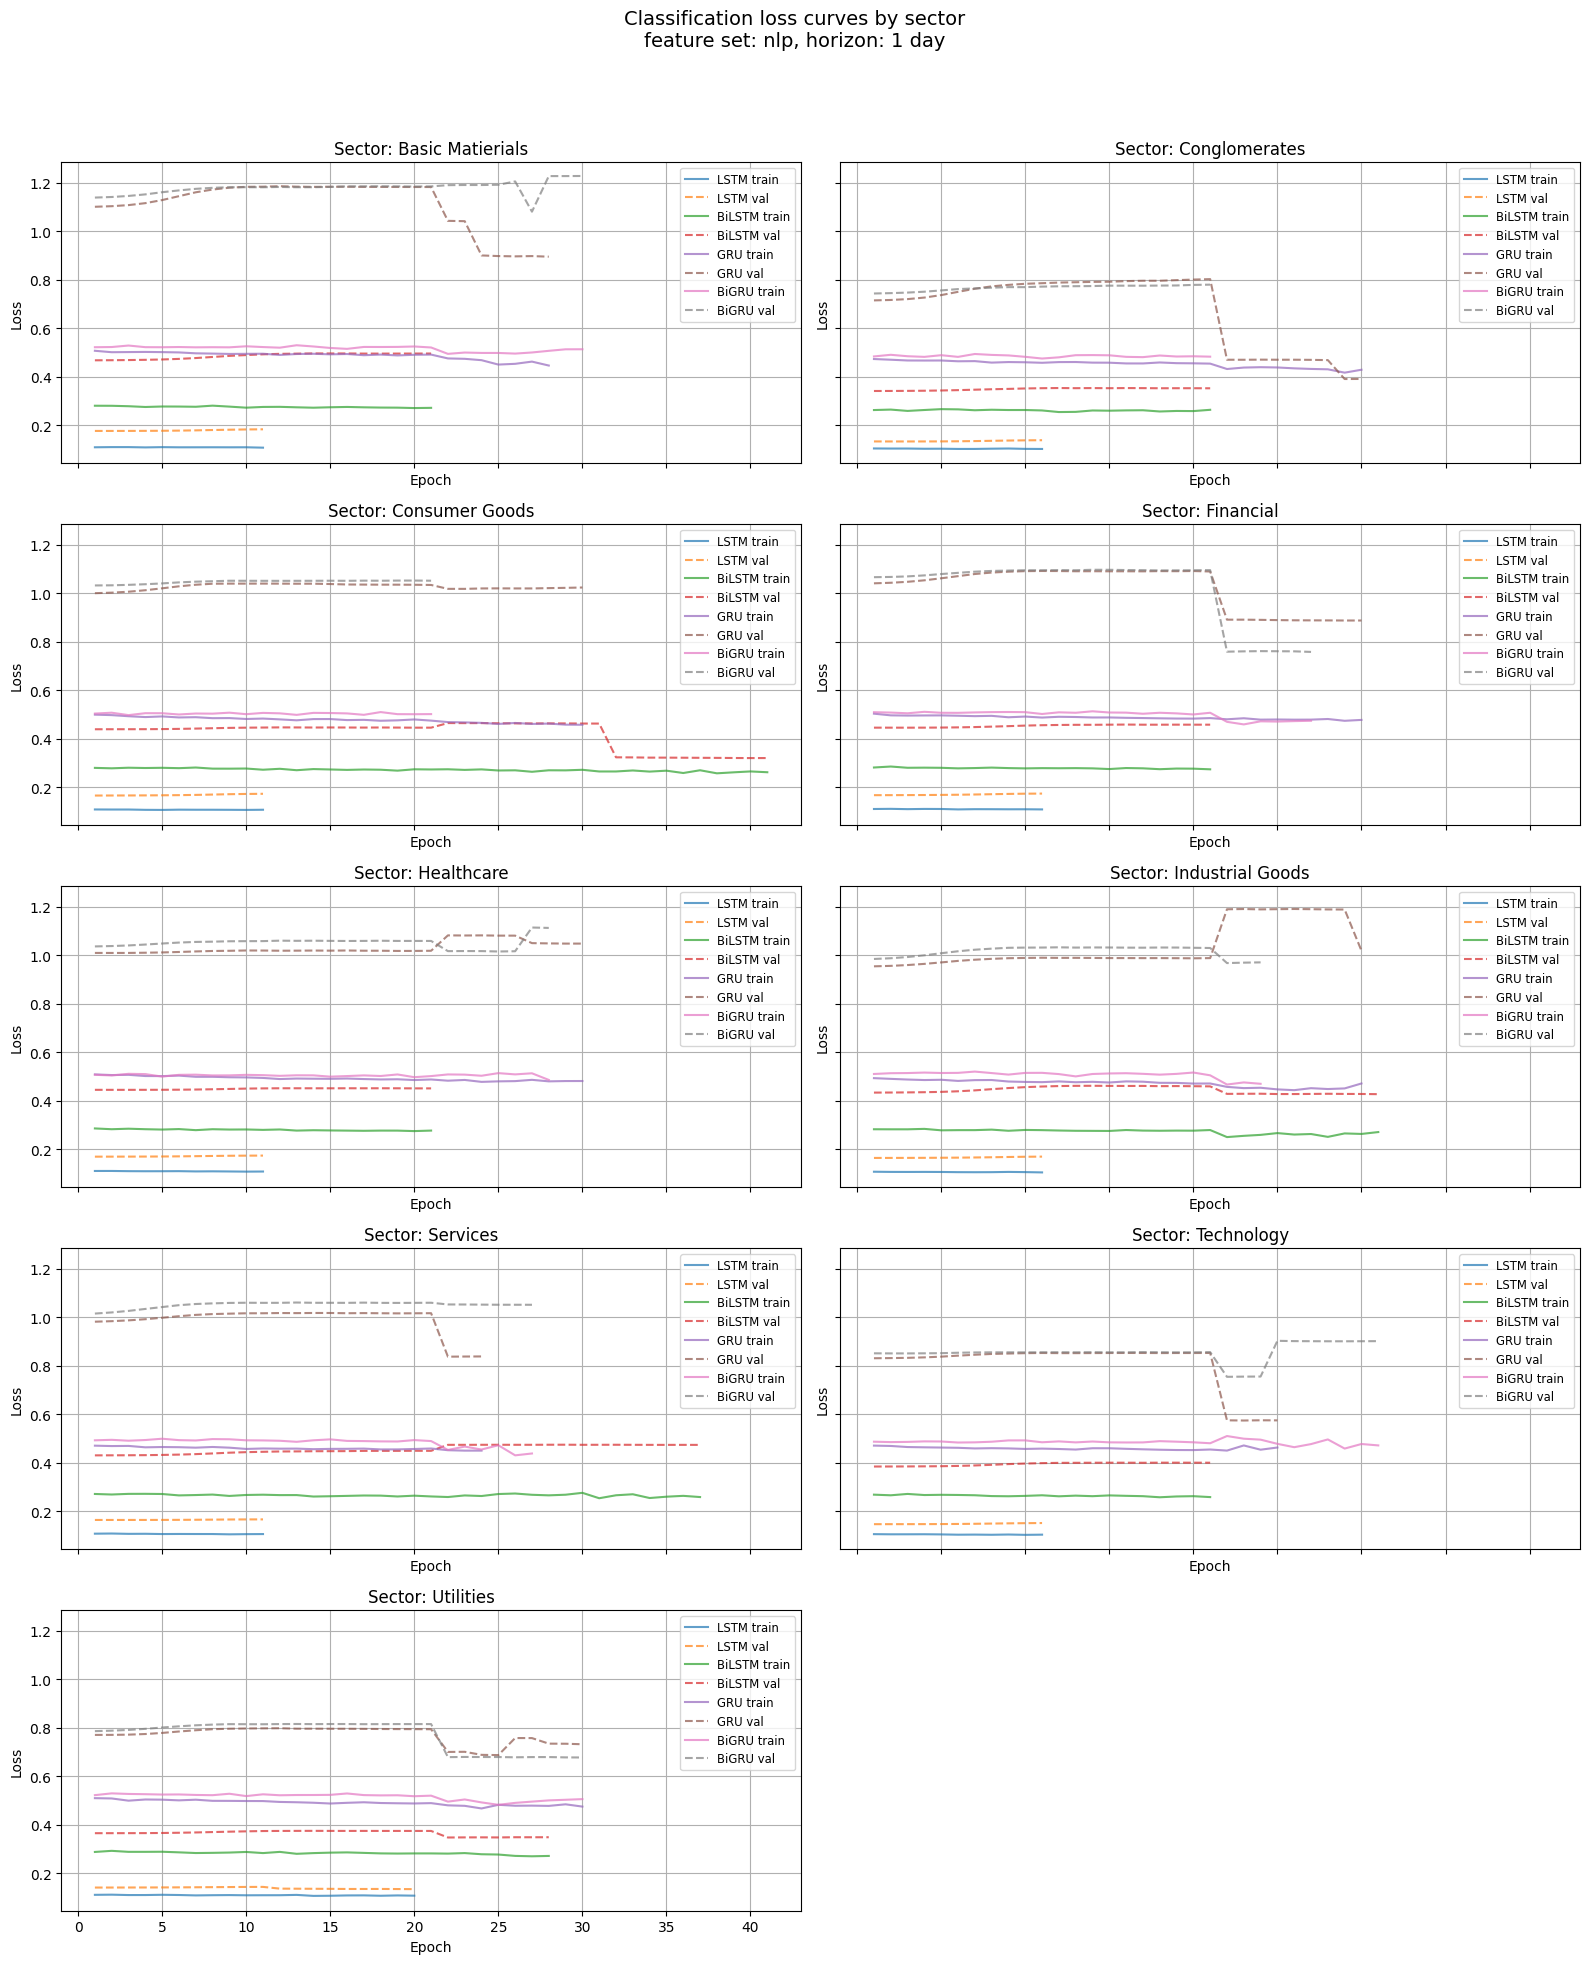

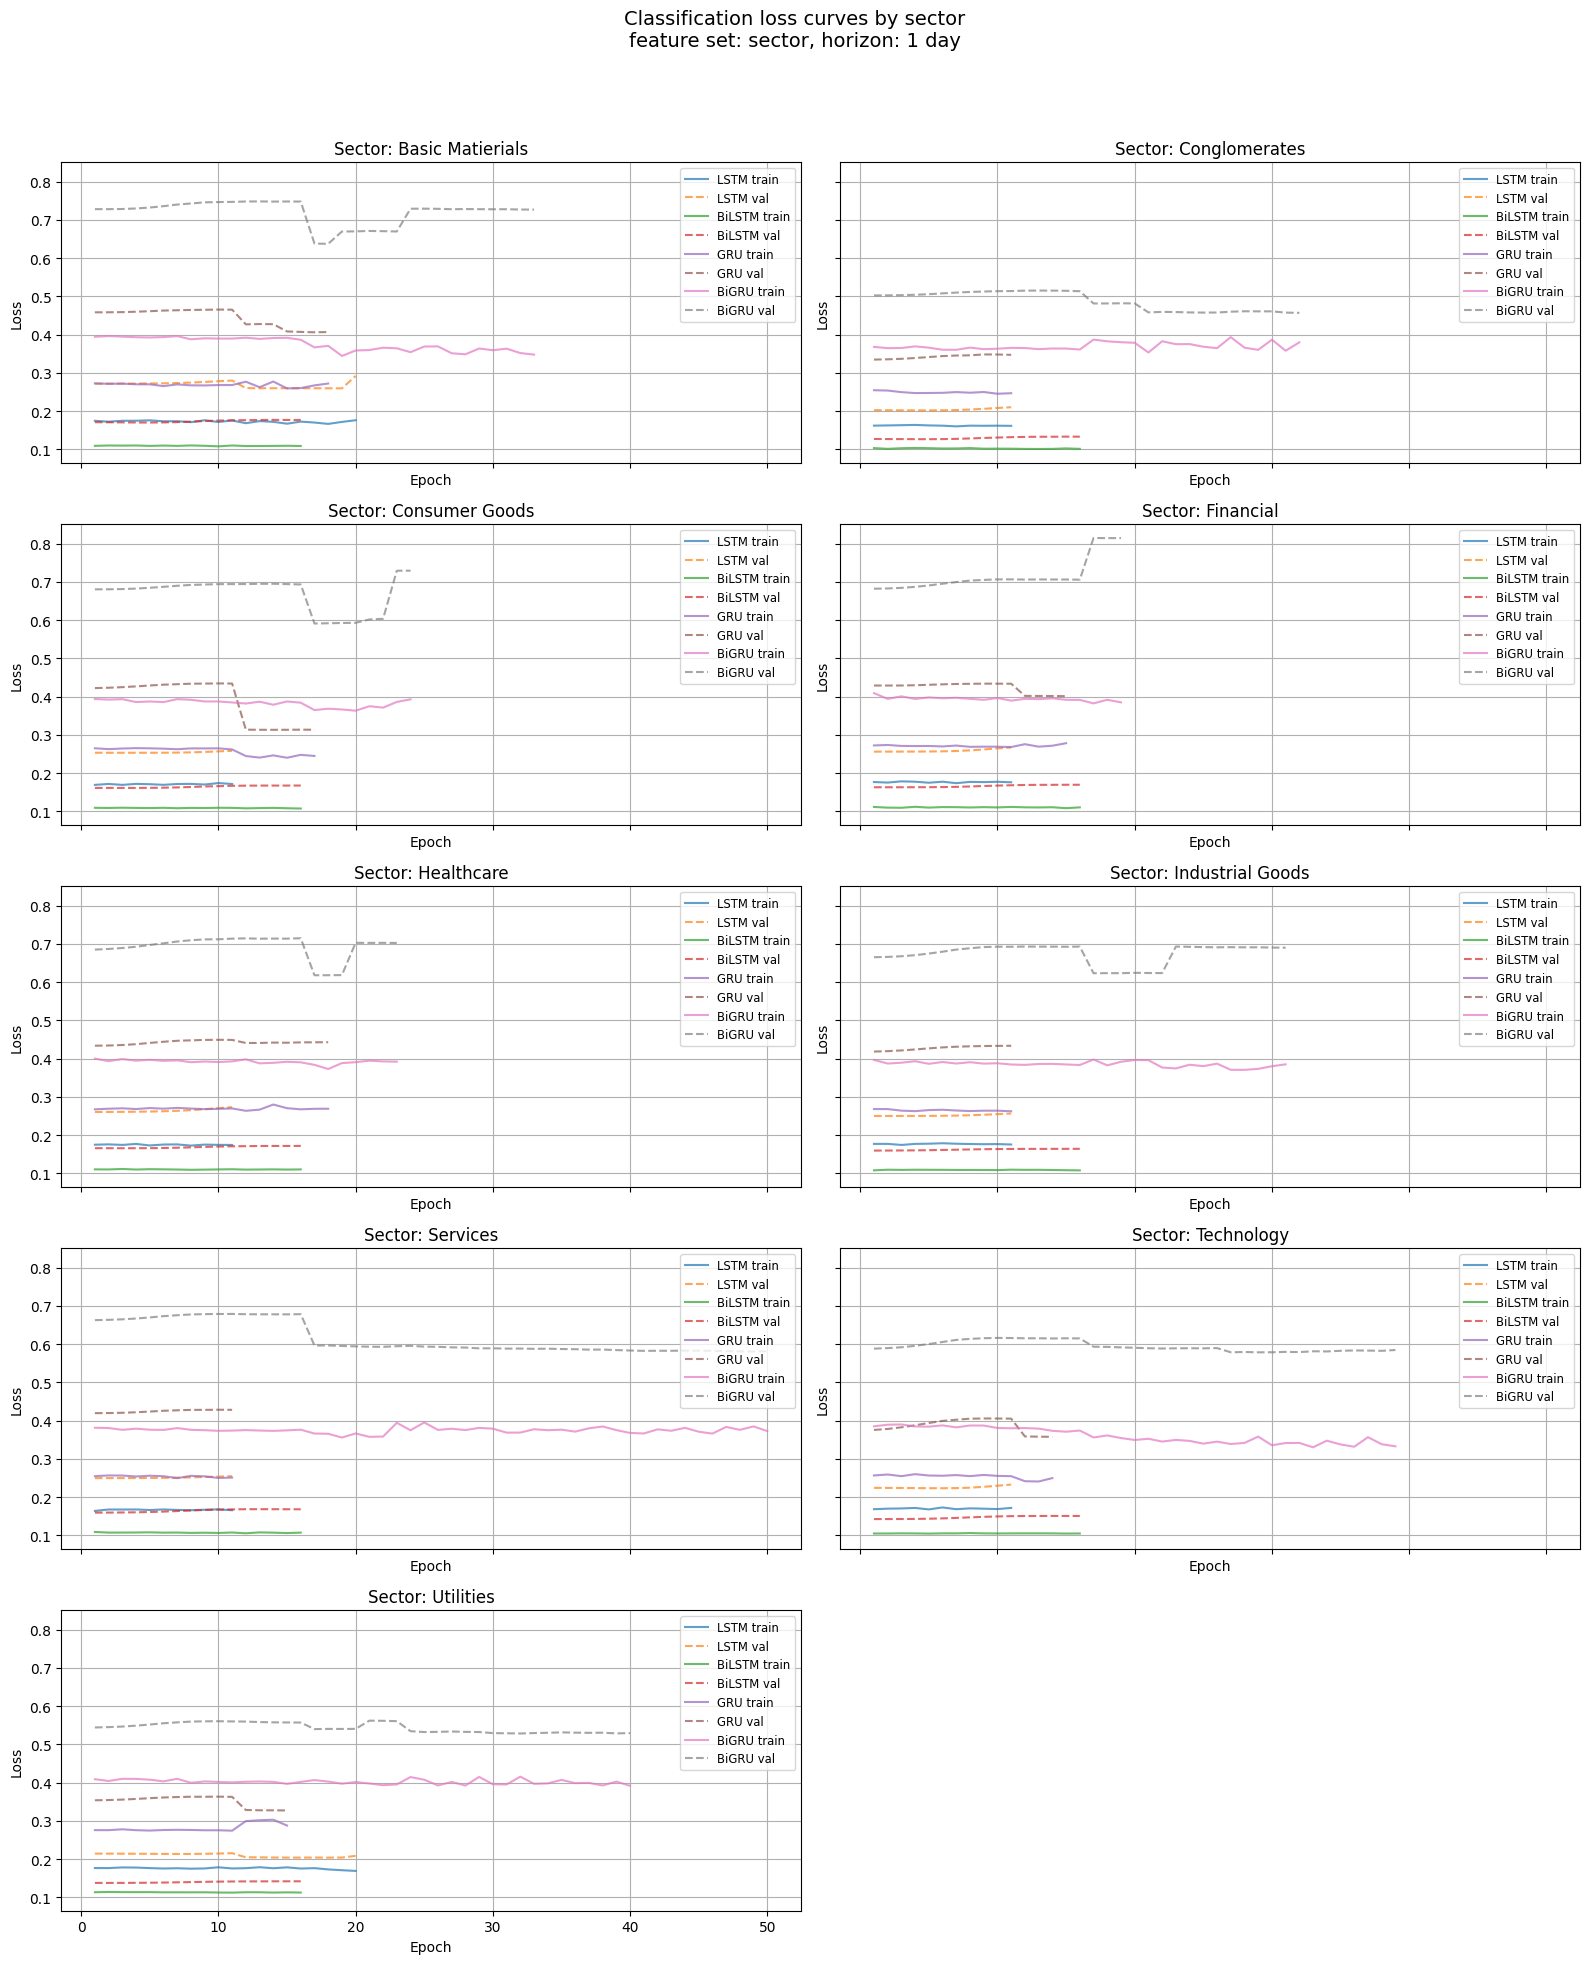

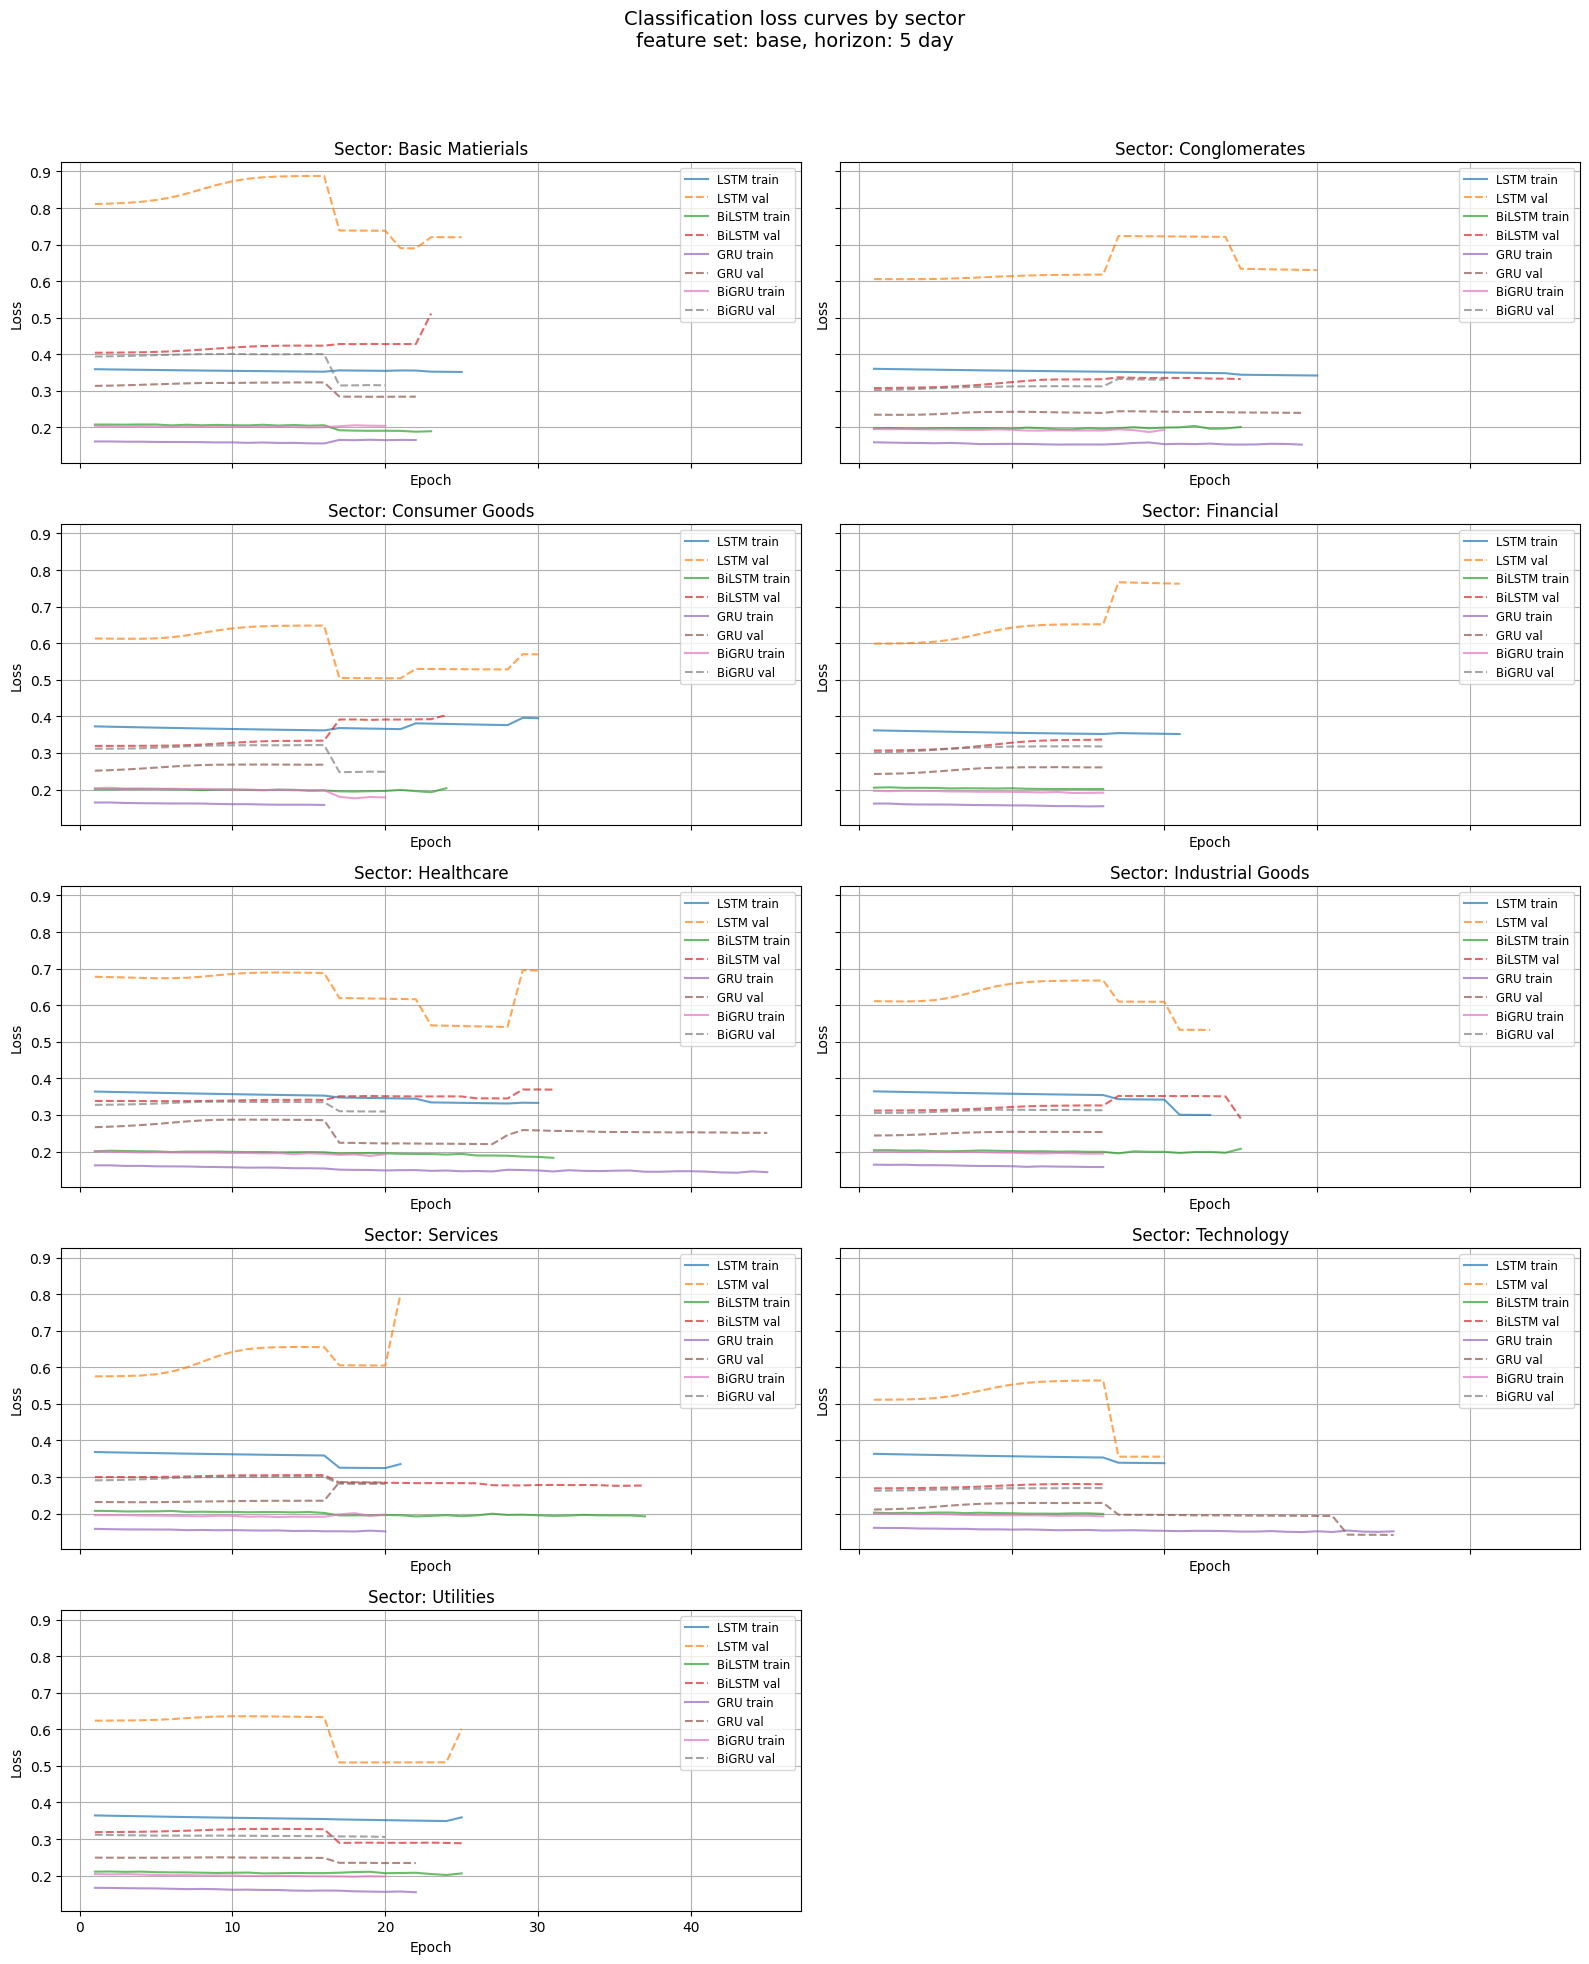

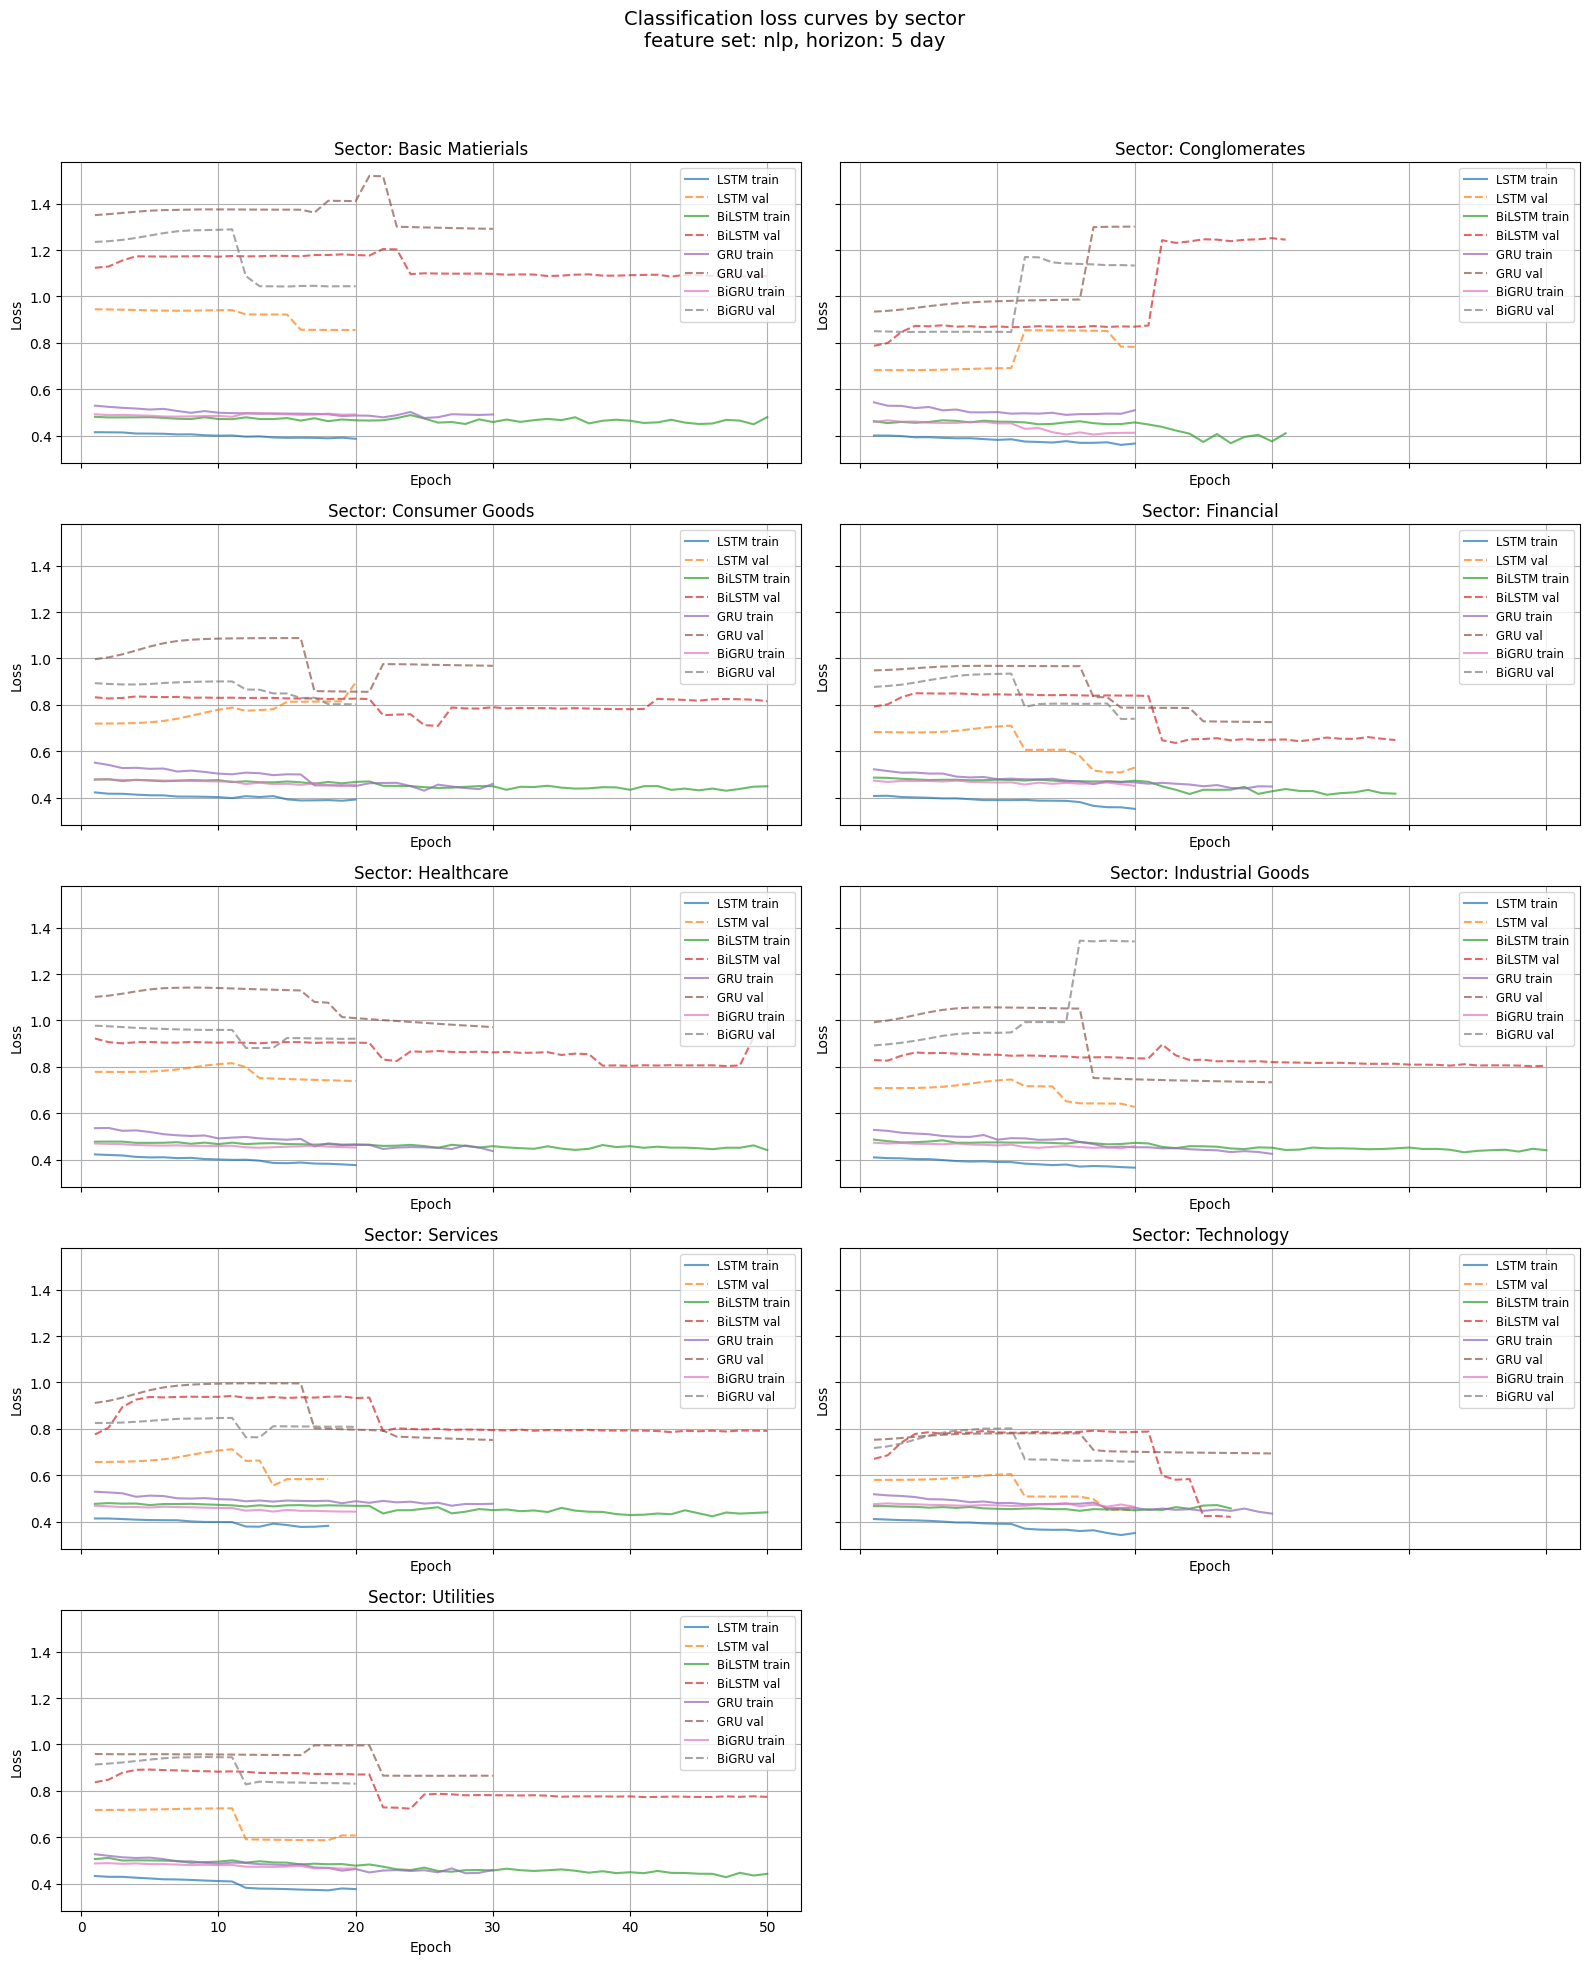

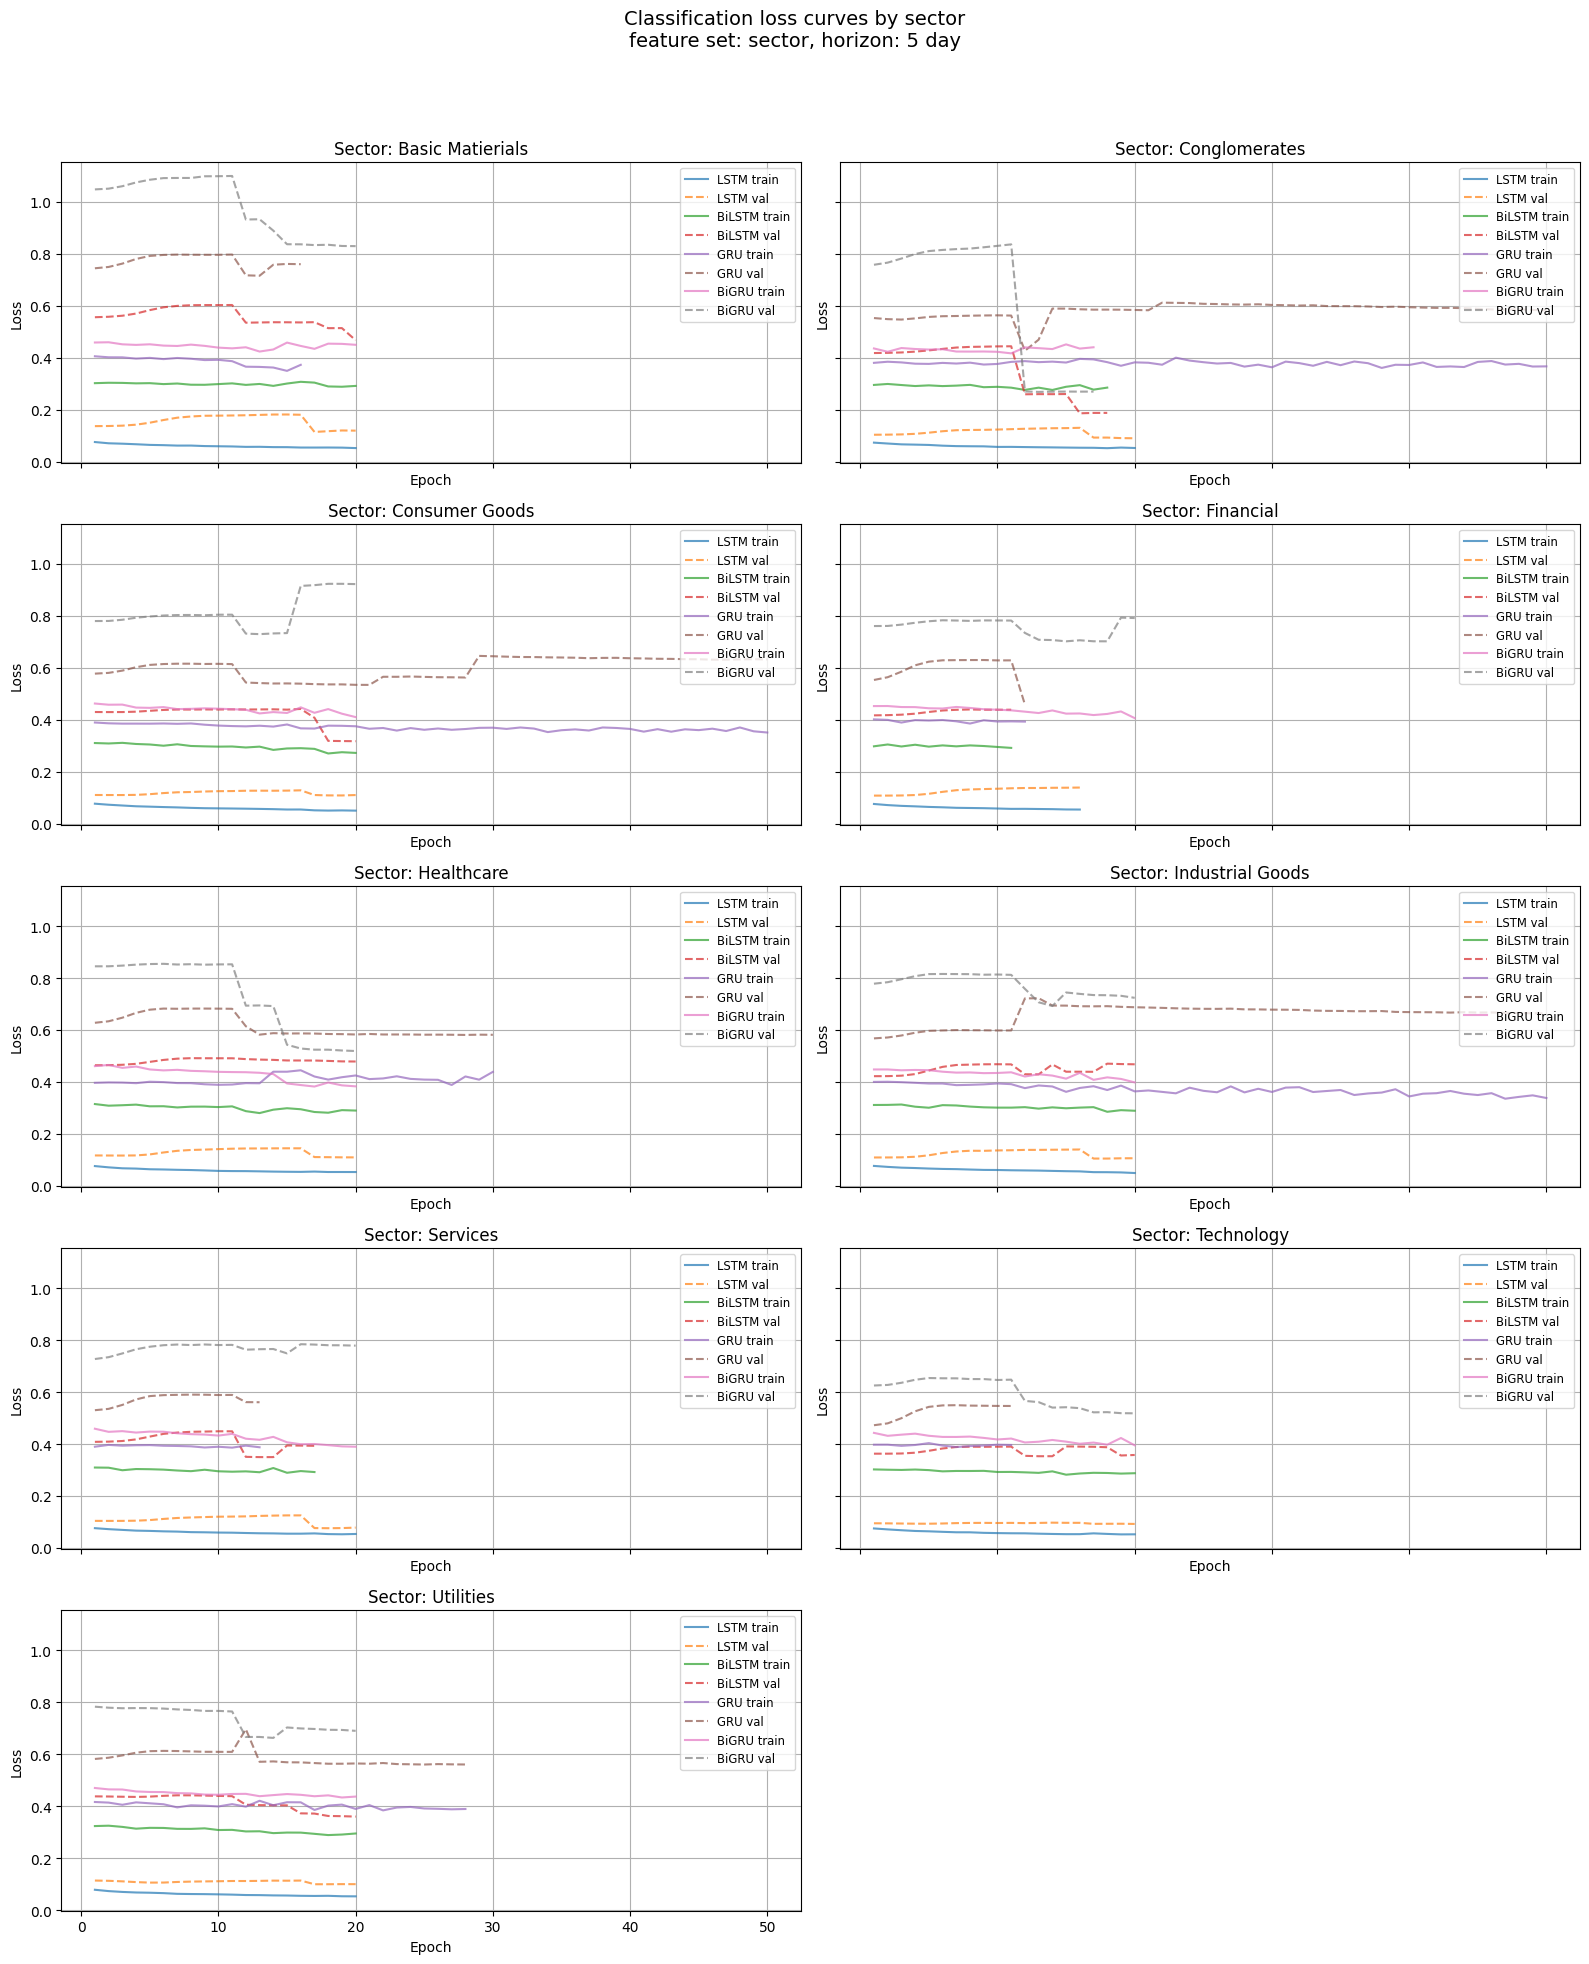

In [27]:
for h in horizons:
    for feature in features:
        # gather data just for this horizon/feature set
        pieces = []
        for model_name in models:
            csv_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            df["model"] = model_name
            pieces.append(df)
        if not pieces:                          # nothing to plot
            continue

        combined_df = pd.concat(pieces, ignore_index=True)
        grouped_loss = (combined_df
                        .groupby(["sector", "model", "epoch"])
                        [["train_loss", "val_loss"]]
                        .mean()
                        .reset_index())

        sectors = grouped_loss["sector"].unique()
        n_cols = 2
        n_rows = -(-len(sectors) // n_cols)

        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(16, 4 * n_rows),
                                 sharex=True, sharey=True)
        axes = axes.flatten()

        for i, sector in enumerate(sectors):
            ax = axes[i]
            sector_data = grouped_loss[grouped_loss["sector"] == sector]
            for model_name in models:
                model_data = sector_data[sector_data["model"] == model_name]
                if model_data.empty:
                    continue
                ax.plot(model_data["epoch"], model_data["train_loss"],
                        label=f"{model_name} train",
                        linestyle="-", alpha=0.7)
                ax.plot(model_data["epoch"], model_data["val_loss"],
                        label=f"{model_name} val",
                        linestyle="--", alpha=0.7)
            ax.set_title(f"Sector: {sector}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.grid(True)
            ax.legend(fontsize="small", loc="upper right")

        # remove any extra empty subplots
        for j in range(len(sectors), len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(
            f"Classification loss curves by sector\n"
            f"feature set: {feature}, horizon: {h} day",
            fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

## Overall Results Table

### Classification

In [29]:
# Overall classification results table + sector details for all models/feature sets/horizons
import pandas as pd
import numpy as np
from pathlib import Path


horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]

summary_rows = []

for h in horizons:
    for model_name in models:
        for feature in features:
            results_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_results.csv"
            params_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_params.csv"
            if not results_path.exists():
                print(f"[SKIP] Missing results: {results_path}")
                continue

            df = pd.read_csv(results_path)
            params_df = pd.read_csv(params_path)

            # Get feature set from params file (10th column, index 9)
            feature_set_value = params_df.iloc[0, 9] if len(params_df.columns) > 9 else feature

            # Overall metrics
            overall = {
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature_set_value, 
                "Companies": len(df),
                "Avg Samples/Company": df["n_samples"].mean() if "n_samples" in df.columns else np.nan,
                "Dir Acc Mean": df["directional_accuracy"].mean() if "directional_accuracy" in df.columns else np.nan,
                "Dir Acc Std": df["directional_accuracy"].std() if "directional_accuracy" in df.columns else np.nan,
                "MCC Mean": df["mcc"].mean() if "mcc" in df.columns else np.nan,
                "MCC Std": df["mcc"].std() if "mcc" in df.columns else np.nan,
                "F1 Mean": df["f1"].mean() if "f1" in df.columns else np.nan,
                "F1 Std": df["f1"].std() if "f1" in df.columns else np.nan,
                "Precision Mean": df["precision"].mean() if "precision" in df.columns else np.nan,
                "Precision Std": df["precision"].std() if "precision" in df.columns else np.nan,
                "Recall Mean": df["recall"].mean() if "recall" in df.columns else np.nan,
                "Recall Std": df["recall"].std() if "recall" in df.columns else np.nan,
            }
            summary_rows.append(overall)

            # Detailed printout
            print("="*50)
            print(f"Model: {model_name} | Problem: classification | Horizon: {h}H | Feature: {feature}")
            print(f"Companies analyzed: {len(df)}")
            if "n_samples" in df.columns:
                print(f"Average samples per company: {df['n_samples'].mean():.0f}")
            print("="*50)
            print("OVERALL PERFORMANCE")
            print("="*50)
            if "directional_accuracy" in df.columns:
                print(f"Directional Accuracy:   {df['directional_accuracy'].mean():.4f} (±{df['directional_accuracy'].std():.4f})")
            if "mcc" in df.columns:
                print(f"Matthews Correlation:   {df['mcc'].mean():.4f} (±{df['mcc'].std():.4f})")
            if "f1" in df.columns:
                print(f"F1 Score:              {df['f1'].mean():.4f} (±{df['f1'].std():.4f})")
            if "precision" in df.columns:
                print(f"Precision:             {df['precision'].mean():.4f} (±{df['precision'].std():.4f})")
            if "recall" in df.columns:
                print(f"Recall:                {df['recall'].mean():.4f} (±{df['recall'].std():.4f})")

            # Performance by sector
            if "sector" in df.columns:
                print("="*50)
                print("PERFORMANCE BY SECTOR")
                print("="*50)
                sector_stats = df.groupby('sector').agg({
                    'directional_accuracy': ['mean', 'std', 'count'],
                    'mcc': ['mean']
                })
                sector_stats.columns = ['dir_acc_mean', 'dir_acc_std', 'count', 'mcc_mean']
                sector_stats = sector_stats.sort_values('dir_acc_mean', ascending=False)
                for sector, row in sector_stats.iterrows():
                    print(f"{sector:<18} | Acc: {row['dir_acc_mean']:.3f}±{row['dir_acc_std']:.3f} | MCC: {row['mcc_mean']:.3f} | Companies: {int(row['count'])}")

            # Top performers
            if "directional_accuracy" in df.columns:
                print("="*50)
                print("TOP 10 PERFORMERS (by Directional Accuracy)")
                print("="*50)
                top = df.nlargest(10, 'directional_accuracy')
                for _, row in top.iterrows():
                    sector = row['sector'] if 'sector' in row else 'N/A'
                    company = row['company'] if 'company' in row else row.get('ticker', 'N/A')
                    print(f"{company:<18} | {sector:<15} | Acc: {row['directional_accuracy']:.3f} | MCC: {row['mcc']:.3f}")

# Print overall summary table
summary_df = pd.DataFrame(summary_rows)
# sort by horizon (ascending) then by MCC mean (descending)
summary_df = summary_df.sort_values(by=['Horizon', 'MCC Mean'], ascending=[True, False])

print("\n=== OVERALL SUMMARY TABLE (1-Day Horizon) ===")
summary_1d = summary_df[summary_df['Horizon'] == 1].drop('Horizon', axis=1)
print(summary_1d.to_string(index=False))

print("\n=== OVERALL SUMMARY TABLE (5-Day Horizon) ===")
summary_5d = summary_df[summary_df['Horizon'] == 5].drop('Horizon', axis=1)
print(summary_5d.to_string(index=False))


Model: LSTM | Problem: classification | Horizon: 1H | Feature: base
Companies analyzed: 87
Average samples per company: 1184
OVERALL PERFORMANCE
Directional Accuracy:   0.5160 (±0.0576)
Matthews Correlation:   0.0687 (±0.1055)
F1 Score:              0.4045 (±0.2555)
Precision:             0.5075 (±0.2634)
Recall:                0.4860 (±0.3817)
PERFORMANCE BY SECTOR
Financial          | Acc: 0.547±0.079 | MCC: 0.105 | Companies: 10
Healthcare         | Acc: 0.527±0.070 | MCC: 0.117 | Companies: 10
Technology         | Acc: 0.525±0.048 | MCC: 0.110 | Companies: 10
Consumer Goods     | Acc: 0.523±0.060 | MCC: 0.056 | Companies: 10
Utilities          | Acc: 0.520±0.052 | MCC: 0.014 | Companies: 10
Basic Matierials   | Acc: 0.506±0.063 | MCC: 0.048 | Companies: 10
Industrial Goods   | Acc: 0.506±0.059 | MCC: 0.057 | Companies: 10
Conglomerates      | Acc: 0.496±0.040 | MCC: 0.070 | Companies: 7
Services           | Acc: 0.487±0.029 | MCC: 0.043 | Companies: 10
TOP 10 PERFORMERS (by Directi

In [32]:
horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]

# ---- AUC TABLE FROM LOSS CURVES ----
auc_rows = []
for h in horizons:
    for model_name in models:
        for feature in features:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                print(f"[SKIP] Missing loss curves: {csv_path}")
                continue
            df = pd.read_csv(csv_path).sort_values(by="epoch")
            auc_train = np.trapz(df["train_loss"], df["epoch"])
            auc_val = np.trapz(df["val_loss"], df["epoch"])
            auc_rows.append({
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature,
                "AUC_Train": auc_train,
                "AUC_Validation": auc_val,
            })

auc_df = pd.DataFrame(auc_rows)
print("=== AUC TABLE (LOSS CURVES) ===")
print(auc_df.to_string(index=False))

# ---- DETAILED RESULTS FROM RESULTS CSVs ----
summary_rows = []

for h in horizons:
    for model_name in models:
        for feature in features:
            results_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_results.csv"
            if not results_path.exists():
                print(f"[SKIP] Missing results: {results_path}")
                continue

            df = pd.read_csv(results_path)

            # Overall metrics summary row
            overall = {
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature,
                "Companies": len(df),
                "Avg Samples/Company": df["n_samples"].mean() if "n_samples" in df.columns else np.nan,
                "Dir Acc Mean": df["directional_accuracy"].mean() if "directional_accuracy" in df.columns else np.nan,
                "Dir Acc Std": df["directional_accuracy"].std() if "directional_accuracy" in df.columns else np.nan,
                "MCC Mean": df["mcc"].mean() if "mcc" in df.columns else np.nan,
                "MCC Std": df["mcc"].std() if "mcc" in df.columns else np.nan,
                "F1 Mean": df["f1"].mean() if "f1" in df.columns else np.nan,
                "F1 Std": df["f1"].std() if "f1" in df.columns else np.nan,
                "Precision Mean": df["precision"].mean() if "precision" in df.columns else np.nan,
                "Precision Std": df["precision"].std() if "precision" in df.columns else np.nan,
                "Recall Mean": df["recall"].mean() if "recall" in df.columns else np.nan,
                "Recall Std": df["recall"].std() if "recall" in df.columns else np.nan,
            }
            summary_rows.append(overall)

            # Detailed printout like the example
            print("" + "="*50)
            print(f"Model: {model_name} | Problem: classification | Horizon: {h}H | Feature: {feature}")
            print(f"Companies analyzed: {len(df)}")
            if "n_samples" in df.columns:
                print(f"Average samples per company: {df['n_samples'].mean():.0f}")
            print("="*50)
            print("OVERALL PERFORMANCE")
            print("="*50)
            if "directional_accuracy" in df.columns:
                print(f"Directional Accuracy:   {df['directional_accuracy'].mean():.4f} (±{df['directional_accuracy'].std():.4f})")
            if "mcc" in df.columns:
                print(f"Matthews Correlation:   {df['mcc'].mean():.4f} (±{df['mcc'].std():.4f})")
            if "f1" in df.columns:
                print(f"F1 Score:              {df['f1'].mean():.4f} (±{df['f1'].std():.4f})")
            if "precision" in df.columns:
                print(f"Precision:             {df['precision'].mean():.4f} (±{df['precision'].std():.4f})")
            if "recall" in df.columns:
                print(f"Recall:                {df['recall'].mean():.4f} (±{df['recall'].std():.4f})")

            # Performance by sector
            if "sector" in df.columns:
                print("="*50)
                print("PERFORMANCE BY SECTOR")
                print("="*50)
                sector_stats = df.groupby('sector').agg({
                    'directional_accuracy': ['mean', 'std', 'count'],
                    'mcc': ['mean']
                })
                sector_stats.columns = ['dir_acc_mean', 'dir_acc_std', 'count', 'mcc_mean']
                sector_stats = sector_stats.sort_values('dir_acc_mean', ascending=False)
                for sector, row in sector_stats.iterrows():
                    print(f"{sector:<18} | Acc: {row['dir_acc_mean']:.3f}±{row['dir_acc_std']:.3f} | MCC: {row['mcc_mean']:.3f} | Companies: {int(row['count'])}")

            # Top performers
            if "directional_accuracy" in df.columns:
                print("="*50)
                print("TOP 10 PERFORMERS (by Directional Accuracy)")
                print("="*50)
                top = df.nlargest(10, 'directional_accuracy')
                for _, row in top.iterrows():
                    sector = row['sector'] if 'sector' in row else 'N/A'
                    company = row['company'] if 'company' in row else row.get('ticker', 'N/A')
                    print(f"{company:<18} | {sector:<15} | Acc: {row['directional_accuracy']:.3f} | MCC: {row['mcc']:.3f}")

# Print overall summary table
summary_df = pd.DataFrame(summary_rows)
print("=== OVERALL SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

=== AUC TABLE (LOSS CURVES) ===
 Model  Horizon Feature Set  AUC_Train  AUC_Validation
  LSTM        1        base  16.750327       63.891083
  LSTM        1         nlp  12.520390       20.378419
  LSTM        1      sector  24.031131       52.438519
BiLSTM        1        base  16.735672       22.124727
BiLSTM        1         nlp  13.763609       44.975117
BiLSTM        1      sector  12.010138       21.776548
   GRU        1        base  16.506147       72.786164
   GRU        1         nlp  11.577178       34.535050
   GRU        1      sector   7.506288       46.409541
 BiGRU        1        base  13.634506       75.988286
 BiGRU        1         nlp  10.890611       35.566008
 BiGRU        1      sector  11.583107       28.074544
  LSTM        5        base  10.070757       27.204305
  LSTM        5         nlp   5.835118       84.305865
  LSTM        5      sector  11.637370       26.404350
BiLSTM        5        base   6.673731       39.028036
BiLSTM        5         nlp   7.8

In [ ]:
# Overall regression results table + sector details for all models/feature sets/horizons
import pandas as pd
import numpy as np
from pathlib import Path


horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]

summary_rows = []

for h in horizons:
    for model_name in models:
        for feature in features:
            results_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_results.csv"
            params_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_params.csv"
            if not results_path.exists():
                print(f"[SKIP] Missing results: {results_path}")
                continue

            df = pd.read_csv(results_path)
            params_df = pd.read_csv(params_path)

            # Get feature set from params file (10th column, index 9)
            feature_set_value = params_df.iloc[0, 9] if len(params_df.columns) > 9 else feature

            # Overall metrics
            overall = {
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature_set_value, 
                "Companies": len(df),
                "Avg Samples/Company": df["n_samples"].mean() if "n_samples" in df.columns else np.nan,
                "Dir Acc Mean": df["directional_accuracy"].mean() if "directional_accuracy" in df.columns else np.nan,
                "Dir Acc Std": df["directional_accuracy"].std() if "directional_accuracy" in df.columns else np.nan,
                "MCC Mean": df["mcc"].mean() if "mcc" in df.columns else np.nan,
                "MCC Std": df["mcc"].std() if "mcc" in df.columns else np.nan,
                "F1 Mean": df["f1"].mean() if "f1" in df.columns else np.nan,
                "F1 Std": df["f1"].std() if "f1" in df.columns else np.nan,
                "Precision Mean": df["precision"].mean() if "precision" in df.columns else np.nan,
                "Precision Std": df["precision"].std() if "precision" in df.columns else np.nan,
                "Recall Mean": df["recall"].mean() if "recall" in df.columns else np.nan,
                "Recall Std": df["recall"].std() if "recall" in df.columns else np.nan,
            }
            summary_rows.append(overall)

            # Detailed printout
            print("="*50)
            print(f"Model: {model_name} | Problem: regression | Horizon: {h}H | Feature: {feature}")
            print(f"Companies analyzed: {len(df)}")
            if "n_samples" in df.columns:
                print(f"Average samples per company: {df['n_samples'].mean():.0f}")
            print("="*50)
            print("OVERALL PERFORMANCE")
            print("="*50)
            
            if "directional_accuracy" in df.columns:
                print(f"Directional Accuracy:   {df['directional_accuracy'].mean():.4f} (±{df['directional_accuracy'].std():.4f})")
            if "mcc" in df.columns:
                print(f"Matthews Correlation:   {df['mcc'].mean():.4f} (±{df['mcc'].std():.4f})")
            if "f1" in df.columns:
                print(f"F1 Score:              {df['f1'].mean():.4f} (±{df['f1'].std():.4f})")
            if "precision" in df.columns:
                print(f"Precision:             {df['precision'].mean():.4f} (±{df['precision'].std():.4f})")
            if "recall" in df.columns:
                print(f"Recall:                {df['recall'].mean():.4f} (±{df['recall'].std():.4f})")

            # Performance by sector
            if "sector" in df.columns:
                print("="*50)
                print("PERFORMANCE BY SECTOR")
                print("="*50)
                sector_stats = df.groupby('sector').agg({
                    'directional_accuracy': ['mean', 'std', 'count'],
                    'mcc': ['mean']
                })
                sector_stats.columns = ['dir_acc_mean', 'dir_acc_std', 'count', 'mcc_mean']
                sector_stats = sector_stats.sort_values('dir_acc_mean', ascending=False)
                for sector, row in sector_stats.iterrows():
                    print(f"{sector:<18} | Acc: {row['dir_acc_mean']:.3f}±{row['dir_acc_std']:.3f} | MCC: {row['mcc_mean']:.3f} | Companies: {int(row['count'])}")

            # Top performers
            if "directional_accuracy" in df.columns:
                print("="*50)
                print("TOP 10 PERFORMERS (by Directional Accuracy)")
                print("="*50)
                top = df.nlargest(10, 'directional_accuracy')
                for _, row in top.iterrows():
                    sector = row['sector'] if 'sector' in row else 'N/A'
                    company = row['company'] if 'company' in row else row.get('ticker', 'N/A')
                    print(f"{company:<18} | {sector:<15} | Acc: {row['directional_accuracy']:.3f} | MCC: {row['mcc']:.3f}")

# Print overall summary table
summary_df = pd.DataFrame(summary_rows)
# sort by horizon (ascending) then by MCC mean (descending)
summary_df = summary_df.sort_values(by=['Horizon', 'MCC Mean'], ascending=[True, False])

print("\n=== OVERALL SUMMARY TABLE (1-Day Horizon) ===")
summary_1d = summary_df[summary_df['Horizon'] == 1].drop('Horizon', axis=1)
print(summary_1d.to_string(index=False))

print("\n=== OVERALL SUMMARY TABLE (5-Day Horizon) ===")
summary_5d = summary_df[summary_df['Horizon'] == 5].drop('Horizon', axis=1)
print(summary_5d.to_string(index=False))


Model: LSTM | Problem: classification | Horizon: 1H | Feature: base
Companies analyzed: 87
Average samples per company: 1184
OVERALL PERFORMANCE
Directional Accuracy:   0.5047 (±0.0519)
Matthews Correlation:   0.0222 (±0.0821)
F1 Score:              0.4080 (±0.2870)
Precision:             0.3910 (±0.2583)
Recall:                0.5499 (±0.4388)
PERFORMANCE BY SECTOR
Services           | Acc: 0.525±0.036 | MCC: 0.018 | Companies: 10
Financial          | Acc: 0.516±0.058 | MCC: 0.035 | Companies: 10
Technology         | Acc: 0.514±0.051 | MCC: 0.034 | Companies: 10
Consumer Goods     | Acc: 0.509±0.043 | MCC: 0.016 | Companies: 10
Healthcare         | Acc: 0.506±0.054 | MCC: 0.053 | Companies: 10
Utilities          | Acc: 0.505±0.062 | MCC: 0.038 | Companies: 10
Basic Matierials   | Acc: 0.491±0.058 | MCC: 0.024 | Companies: 10
Conglomerates      | Acc: 0.489±0.064 | MCC: -0.013 | Companies: 7
Industrial Goods   | Acc: 0.483±0.046 | MCC: -0.016 | Companies: 10
TOP 10 PERFORMERS (by Direc

In [ ]:
horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]

# ---- AUC TABLE FROM LOSS CURVES ----
auc_rows = []
for h in horizons:
    for model_name in models:
        for feature in features:
            csv_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                print(f"[SKIP] Missing loss curves: {csv_path}")
                continue
            df = pd.read_csv(csv_path).sort_values(by="epoch")
            auc_train = np.trapz(df["train_loss"], df["epoch"])
            auc_val = np.trapz(df["val_loss"], df["epoch"])
            auc_rows.append({
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature,
                "AUC_Train": auc_train,
                "AUC_Validation": auc_val,
            })

auc_df = pd.DataFrame(auc_rows)
print("=== AUC TABLE (LOSS CURVES) ===")
print(auc_df.to_string(index=False))

# ---- DETAILED RESULTS FROM RESULTS CSVs ----
summary_rows = []

for h in horizons:
    for model_name in models:
        for feature in features:
            results_path = REGRESSION_RESULTS_PATH / feature / f"{model_name}_{h}H_results.csv"
            if not results_path.exists():
                print(f"[SKIP] Missing results: {results_path}")
                continue

            df = pd.read_csv(results_path)

            # Overall metrics summary row
            overall = {
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature,
                "Companies": len(df),
                "Avg Samples/Company": df["n_samples"].mean() if "n_samples" in df.columns else np.nan,
                "Dir Acc Mean": df["directional_accuracy"].mean() if "directional_accuracy" in df.columns else np.nan,
                "Dir Acc Std": df["directional_accuracy"].std() if "directional_accuracy" in df.columns else np.nan,
                "MCC Mean": df["mcc"].mean() if "mcc" in df.columns else np.nan,
                "MCC Std": df["mcc"].std() if "mcc" in df.columns else np.nan,
                "F1 Mean": df["f1"].mean() if "f1" in df.columns else np.nan,
                "F1 Std": df["f1"].std() if "f1" in df.columns else np.nan,
                "Precision Mean": df["precision"].mean() if "precision" in df.columns else np.nan,
                "Precision Std": df["precision"].std() if "precision" in df.columns else np.nan,
                "Recall Mean": df["recall"].mean() if "recall" in df.columns else np.nan,
                "Recall Std": df["recall"].std() if "recall" in df.columns else np.nan,
            }
            summary_rows.append(overall)

            # Detailed printout like the example
            print("" + "="*50)
            print(f"Model: {model_name} | Problem: regression | Horizon: {h}H | Feature: {feature}")
            print(f"Companies analyzed: {len(df)}")
            if "n_samples" in df.columns:
                print(f"Average samples per company: {df['n_samples'].mean():.0f}")
            print("="*50)
            print("OVERALL PERFORMANCE")
            print("="*50)
            if "directional_accuracy" in df.columns:
                print(f"Directional Accuracy:   {df['directional_accuracy'].mean():.4f} (±{df['directional_accuracy'].std():.4f})")
            if "mcc" in df.columns:
                print(f"Matthews Correlation:   {df['mcc'].mean():.4f} (±{df['mcc'].std():.4f})")
            if "f1" in df.columns:
                print(f"F1 Score:              {df['f1'].mean():.4f} (±{df['f1'].std():.4f})")
            if "precision" in df.columns:
                print(f"Precision:             {df['precision'].mean():.4f} (±{df['precision'].std():.4f})")
            if "recall" in df.columns:
                print(f"Recall:                {df['recall'].mean():.4f} (±{df['recall'].std():.4f})")

            # Performance by sector
            if "sector" in df.columns:
                print("="*50)
                print("PERFORMANCE BY SECTOR")
                print("="*50)
                sector_stats = df.groupby('sector').agg({
                    'directional_accuracy': ['mean', 'std', 'count'],
                    'mcc': ['mean']
                })
                sector_stats.columns = ['dir_acc_mean', 'dir_acc_std', 'count', 'mcc_mean']
                sector_stats = sector_stats.sort_values('dir_acc_mean', ascending=False)
                for sector, row in sector_stats.iterrows():
                    print(f"{sector:<18} | Acc: {row['dir_acc_mean']:.3f}±{row['dir_acc_std']:.3f} | MCC: {row['mcc_mean']:.3f} | Companies: {int(row['count'])}")

            # Top performers
            if "directional_accuracy" in df.columns:
                print("="*50)
                print("TOP 10 PERFORMERS (by Directional Accuracy)")
                print("="*50)
                top = df.nlargest(10, 'directional_accuracy')
                for _, row in top.iterrows():
                    sector = row['sector'] if 'sector' in row else 'N/A'
                    company = row['company'] if 'company' in row else row.get('ticker', 'N/A')
                    print(f"{company:<18} | {sector:<15} | Acc: {row['directional_accuracy']:.3f} | MCC: {row['mcc']:.3f}")

# Print overall summary table
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by=['Horizon', 'MCC Mean'], ascending=[True, False])
print("=== OVERALL SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

=== AUC TABLE (LOSS CURVES) ===
 Model  Horizon Feature Set  AUC_Train  AUC_Validation
  LSTM        1        base  12.356043       22.424528
  LSTM        1         nlp   2.081759        2.860584
  LSTM        1      sector   3.239726        4.501419
BiLSTM        1        base   4.388266        6.064601
BiLSTM        1         nlp  10.881670       16.652283
BiLSTM        1      sector   1.634624        2.291697
   GRU        1        base   1.725307        2.386197
   GRU        1         nlp  13.900930       27.248439
   GRU        1      sector   4.506071        6.821399
 BiGRU        1        base   2.511385        3.877284
 BiGRU        1         nlp  15.024874       30.091637
 BiGRU        1      sector  18.550566       29.812682
  LSTM        5        base  10.042721       17.613158
  LSTM        5         nlp   7.600428       13.328753
  LSTM        5      sector   1.129791        2.212884
BiLSTM        5        base   7.156125       11.902117
BiLSTM        5         nlp  22.5